# Evolution cycle analysis

In [1215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1216]:
# OPTIONS FOR ANALYSIS
# ('algo' 'corss'/'mut' 'pop'x'gen')
algo = 'NSGA-II' # NSGA-II / NSGA-III / SPEA2 / PAES / MOEA-D

# NSGA-II algorithm:
#ref = '2025-06-14_17-53-11' # NSGA-II 80/10 50x50
#ref = '2025-06-14_16-36-03' # NSGA-II 80/20 50x50 # higher mut
#ref = '2025-06-14_22-45-37' # NSGA-II 80/5 50x50 # lower mut
#ref = '2025-06-14_23-37-07' # NSGA-II 80/10 25x50 # lower pop
#ref = '2025-06-15_12-48-46' # NSGA-II 80/10 100x50 # higher pop
#ref = '2025-06-14_14-33-43' # NSGA-II 80/10 50x100 # higher gen
#ref = '2025-06-15_00-31-00' # NSGA-II 95/5 50x50 # higher cross & lower mut
ref = '2025-06-15_07-16-20' # NSGA-II 95/1 50x100 # mix of best params

# Other algorithms:
#ref = '2025-06-16_15-13-36' # NSGA-III
#ref = '2025-06-16_17-44-33' # SPEA2
#ref = '2025-06-17_01-06-29' # PAES
#ref = '2025-06-17_15-08-47' # MOEA-D

filename = f'{algo}_{ref}'
history_file = f'history/evolution_{filename}'
results_file = f'results/results_{filename}'

In [1217]:
# Set size for graphs in this notebook
figsize=(12, 8)

In [1218]:
df = pd.read_csv(f"{history_file}.csv")
try:
    df_res = pd.read_csv(f"{results_file}.csv")
    Finished = True
except:
    df_res = None
    Finished = False

In [1219]:
# Signaling best individuals found
if Finished: df['best'] = df['fitness'].isin(df_res['fitness'])

## EDA

In [1220]:
n_ind = len(df)
n_hof = len(df_res)

In [1221]:
print(f"Se exploraron {n_ind} individuos, encontrando {n_hof} ganadores ({round(n_hof/n_ind*100,1)}%)")

Se exploraron 4855 individuos, encontrando 174 ganadores (3.6%)


In [1222]:
df.head()

,params,file_size,peaq_score,distortion_index,processing_time,fitness,best
0,"{'ar': '48000', 'sample_fmt': 's16p', 'compres...",179.164062,-3.669,-2.525,0.734796,-0.770109,False
1,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",122.075195,-3.498,-2.042,0.583182,-0.117023,False
2,"{'ar': '32000', 'sample_fmt': 's32p', 'compres...",177.968750,-3.266,-1.586,0.526464,0.482377,False
3,"{'ar': '8000', 'sample_fmt': 'fltp', 'compress...",91.484375,-3.858,-3.510,0.342385,-1.352282,False
4,"{'ar': '48000', 'sample_fmt': 'fltp', 'compres...",106.578125,-3.653,-2.472,0.487288,-0.581994,False


In [1223]:
if Finished: print(df_res.head())

                                              params  file_size  peaq_score  \
0  {'sample_rate': 8000, 'sample_format': 's16p',...  -0.513103   -1.079849   
1  {'sample_rate': 8000, 'sample_format': 'fltp',...  -0.513103   -1.079849   
2  {'sample_rate': 8000, 'sample_format': 's16p',...  -0.511532   -1.079849   
3  {'sample_rate': 8000, 'sample_format': 's32p',...  -0.511532   -1.079849   
4  {'sample_rate': 8000, 'sample_format': 's16p',...  -0.509962   -1.091499   

   distortion_index  processing_time   fitness  
0         -1.404262        -0.354591 -1.226847  
1         -1.405314        -0.429500 -1.223417  
2         -1.404262        -0.412243 -1.224750  
3         -1.405314        -0.437129 -1.223821  
4         -1.452632        -0.443819 -1.250117  


In [1224]:
df.head()

,params,file_size,peaq_score,distortion_index,processing_time,fitness,best
0,"{'ar': '48000', 'sample_fmt': 's16p', 'compres...",179.164062,-3.669,-2.525,0.734796,-0.770109,False
1,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",122.075195,-3.498,-2.042,0.583182,-0.117023,False
2,"{'ar': '32000', 'sample_fmt': 's32p', 'compres...",177.968750,-3.266,-1.586,0.526464,0.482377,False
3,"{'ar': '8000', 'sample_fmt': 'fltp', 'compress...",91.484375,-3.858,-3.510,0.342385,-1.352282,False
4,"{'ar': '48000', 'sample_fmt': 'fltp', 'compres...",106.578125,-3.653,-2.472,0.487288,-0.581994,False


In [1225]:
df.describe()

,file_size,peaq_score,distortion_index,processing_time,fitness
count,4855.000000,4855.000000,4855.000000,4855.000000,4855.000000
mean,202.223751,-3.148830,-1.641792,0.773818,0.680790
std,149.680423,0.482697,0.931942,0.392646,1.205766
min,35.867188,-3.861000,-3.533000,0.336579,-1.495611
25%,52.535156,-3.705000,-2.657000,0.488103,-0.676214
50%,175.128906,-3.180000,-1.447000,0.663292,0.569831
75%,357.319824,-2.596000,-0.711000,0.949419,1.879443
max,446.843750,-2.581000,-0.694000,7.273241,2.127855


In [1226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4855 entries, 0 to 4854
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   params            4855 non-null   object 
 1   file_size         4855 non-null   float64
 2   peaq_score        4855 non-null   float64
 3   distortion_index  4855 non-null   float64
 4   processing_time   4855 non-null   float64
 5   fitness           4855 non-null   float64
 6   best              4855 non-null   bool   
dtypes: bool(1), float64(5), object(1)
memory usage: 232.4+ KB


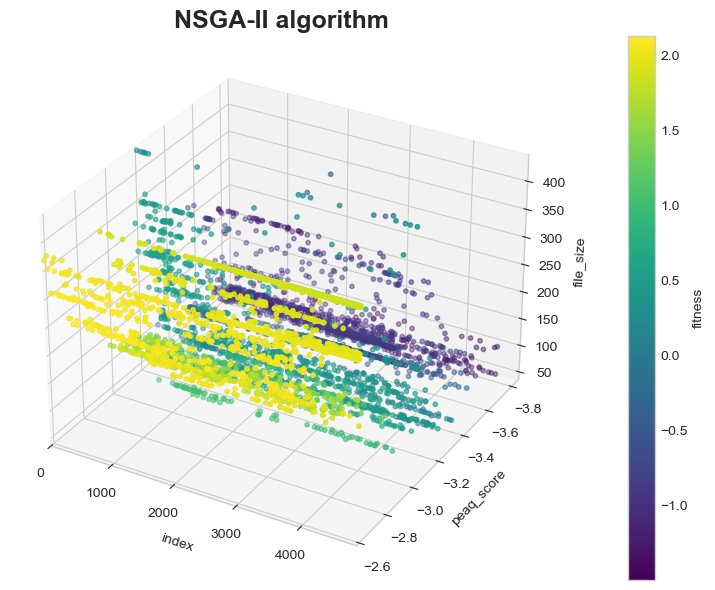

In [1227]:
num_points = len(df)

# Set seaborn style for better aesthetics
sns.set_style("whitegrid")

# Create a 3D figure
fig = plt.figure(figsize=(figsize[0]*0.8, figsize[1]*0.75))
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D scatter plot with 'fitness' determining the color
# 'c' parameter is used to map numerical values to colors, and 'cmap' specifies the colormap
scatter = ax.scatter(
    df.index,         # X-axis
    df['peaq_score'], # Y-axis
    df['file_size'],  # Z-axis (using dfFrame index as requested)
    c=df['fitness'],  # Color based on 'fitness' values
    cmap='viridis',   # Colormap (you can try others like 'plasma', 'magma', 'cividis')
    s=10              # Size of the scatter points
)

# Set labels for each axis
ax.set_xlabel('index')
ax.set_ylabel('peaq_score')
ax.set_zlabel('file_size')

# Set the limits for each axis
ax.set_xlim(0, num_points) # Z-axis limit set to the number of df points
ax.set_ylim(df['peaq_score'].max(), df['peaq_score'].min())
ax.set_zlim(df['file_size'].min(), df['file_size'].max())

# Set the title of the plot
ax.set_title(f'{algo} algorithm', fontsize=18, fontweight='bold')

# Add a color bar to explain the 'fitness' color mapping
cbar = fig.colorbar(scatter, ax=ax, pad=0.08)
cbar.set_label('fitness')

# Display the plot
plt.tight_layout()
plt.show()

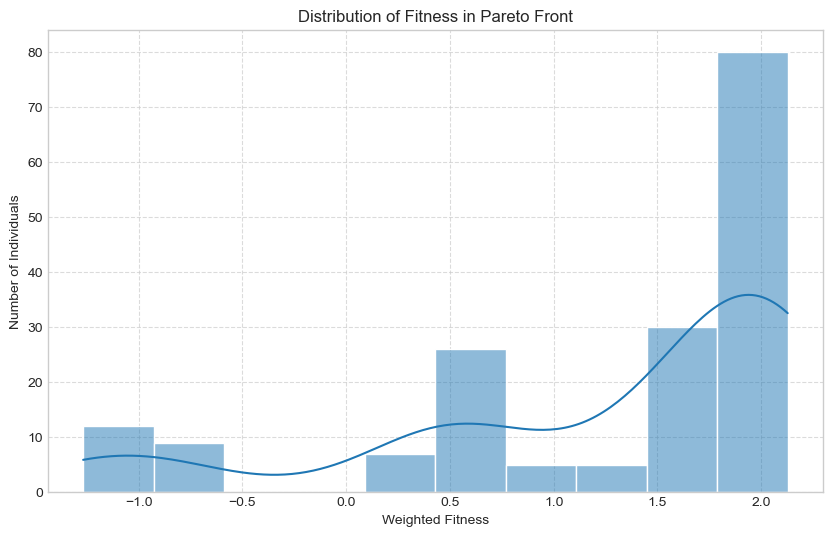

In [1228]:
if Finished: 
    plt.figure(figsize=(10, 6))
    sns.histplot(df_res['fitness'], kde=True, bins=10)
    plt.title('Distribution of Fitness in Pareto Front')
    plt.xlabel('Weighted Fitness')
    plt.ylabel('Number of Individuals')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# History: GA exploration

## Convergence Graph

In [1229]:
# Set desired fitness value (by expert criteria)
convergence_target = 2

In [1230]:
def sub_sample(sampled_data, portion = 0.25):
    sampled_data = sampled_data.copy()
    total_individuals = len(sampled_data)
    num_sample = int(total_individuals * portion)
    sampled_data = sampled_data.sample(num_sample)
    sampled_data = sampled_data.sort_values(by='index')
    return sampled_data

In [1231]:
data_full = df
data_full = data_full.reset_index()
data = sub_sample(data_full)

Subsampled dataframe


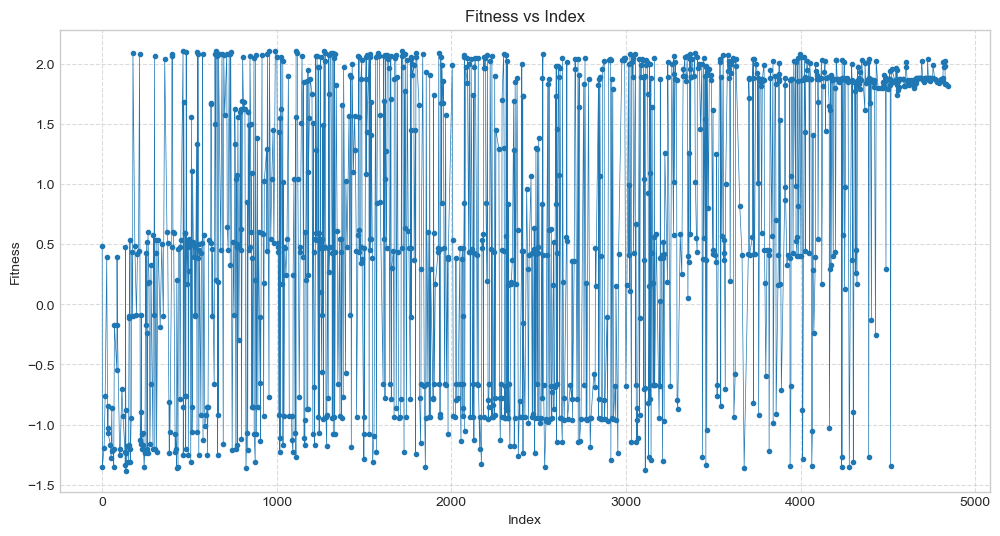

In [1232]:
print('Subsampled dataframe')
plt.figure(figsize=(figsize[0], figsize[1]*0.75))
plt.plot(data['index'], data['fitness'], marker='o', linestyle='-', markersize=3, linewidth=0.5)
plt.xlabel('Index')
plt.ylabel('Fitness')
plt.title('Fitness vs Index')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Subsampled dataframe


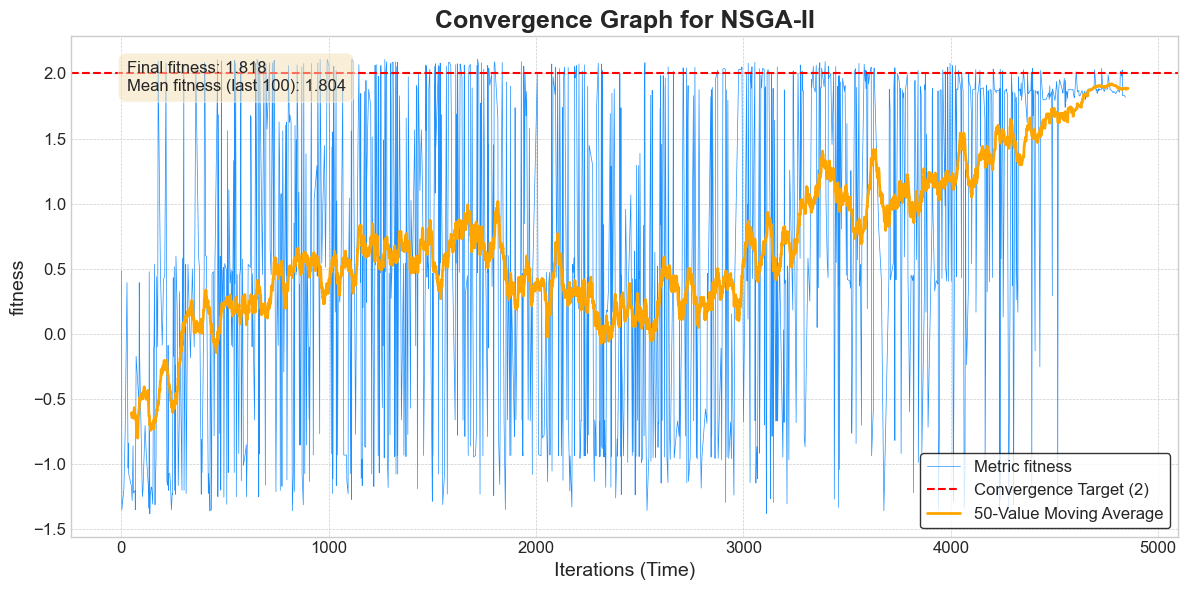

In [1233]:
# --- Create the Convergence Graph ---
print('Subsampled dataframe')
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(figsize[0], figsize[1]*0.75))

# Plot the convergence data
ax.plot(data['index'], data['fitness'], label='Metric fitness', color='dodgerblue', linewidth=0.5)

# Add a horizontal line for the convergence target
ax.axhline(y=convergence_target, color='r', linestyle='--', label=f'Convergence Target ({convergence_target})')

# Calculate the 50-value moving average
data_full['moving_average_50'] = data_full['fitness'].rolling(window=50).mean()

# Plot the 50-value moving average
ax.plot(data_full['index'], data_full['moving_average_50'], label='50-Value Moving Average', color='orange', linewidth=2)

# Customize the plot
ax.set_title(f'Convergence Graph for {algo}', fontsize=18, fontweight='bold')
ax.set_xlabel('Iterations (Time)', fontsize=14)
ax.set_ylabel('fitness', fontsize=14)
ax.legend(fontsize=12, frameon=True, facecolor='white', edgecolor='black') 
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Add a text box with some stats
stats_text = (f"Final fitness: {data['fitness'].iloc[-1]:.3f}\n"
            f"Mean fitness (last 100): {data['fitness'].tail(100).mean():.3f}")
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))


# Show the plot
plt.tight_layout()
plt.show()


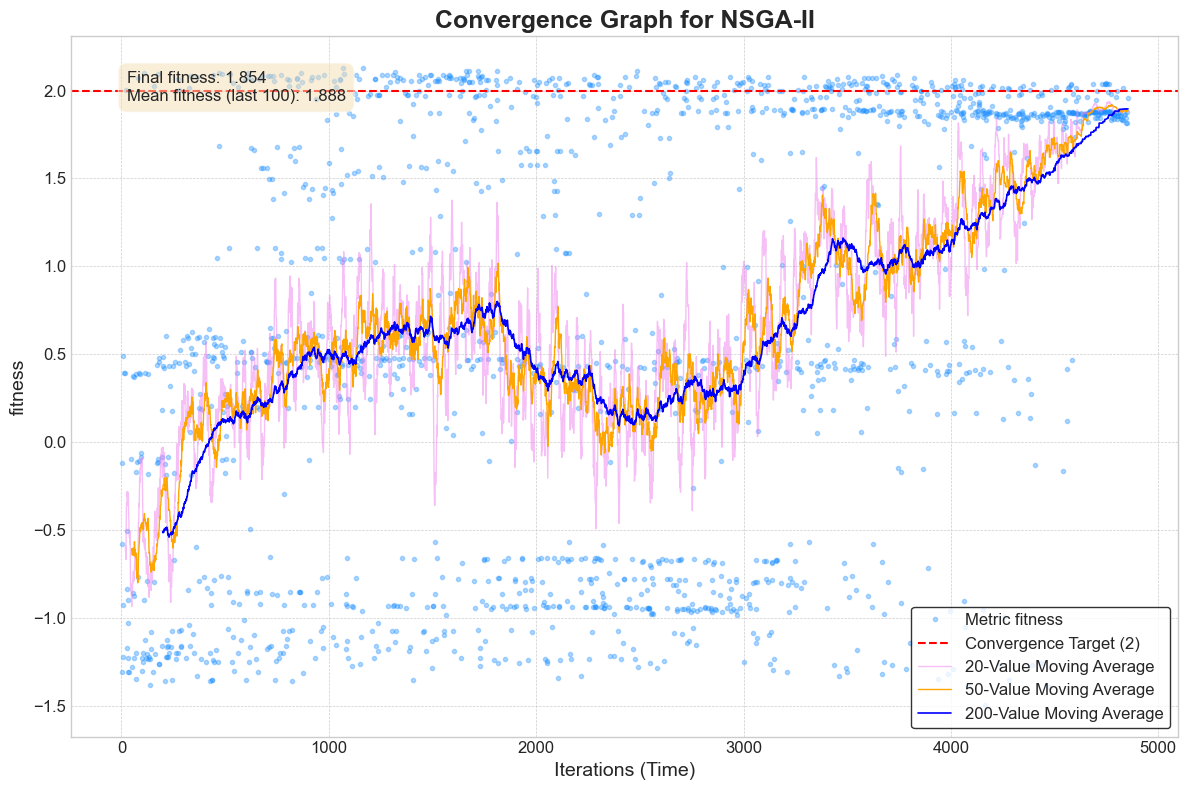

In [1234]:
# Optionally, you could change the amount of individuals showed in the figure
detail_level = 0.35 # percentage of total population (just affects dots)
# It was tuned for better clarity on graph representation

# --- Create the Convergence Graph ---
data = sub_sample(data_full,detail_level)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=figsize)

# Plot the convergence data
ax.plot(data['index'], data['fitness'], label='Metric fitness', color='dodgerblue', marker='.', linestyle='', linewidth=0, alpha=0.35)

# Add a horizontal line for the convergence target
ax.axhline(y=convergence_target, color='r', linestyle='--', label=f'Convergence Target ({convergence_target})')

# Calculate moving averages
data_full['moving_average_20'] = data_full['fitness'].rolling(window=20).mean()
data_full['moving_average_50'] = data_full['fitness'].rolling(window=50).mean()
data_full['moving_average_200'] = data_full['fitness'].rolling(window=200).mean()

# Plot moving averages
ax.plot(data_full['index'], data_full['moving_average_20'], label='20-Value Moving Average', color='violet', linewidth=1, alpha=0.5)
ax.plot(data_full['index'], data_full['moving_average_50'], label='50-Value Moving Average', color='orange', linewidth=1)
ax.plot(data_full['index'], data_full['moving_average_200'], label='200-Value Moving Average', color='blue', linewidth=1.2)

# Customize the plot
ax.set_title(f'Convergence Graph for {algo}', fontsize=18, fontweight='bold')
ax.set_xlabel('Iterations (Time)', fontsize=14)
ax.set_ylabel('fitness', fontsize=14)
ax.legend(fontsize=12, frameon=True, facecolor='white', edgecolor='black') 
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Add a text box with some stats
stats_text = (f"Final fitness: {data_full['fitness'].iloc[-1]:.3f}\n"
            f"Mean fitness (last 100): {data_full['fitness'].tail(100).mean():.3f}")
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Show the plot
plt.tight_layout()
plt.show()


## Multi-objective correlation

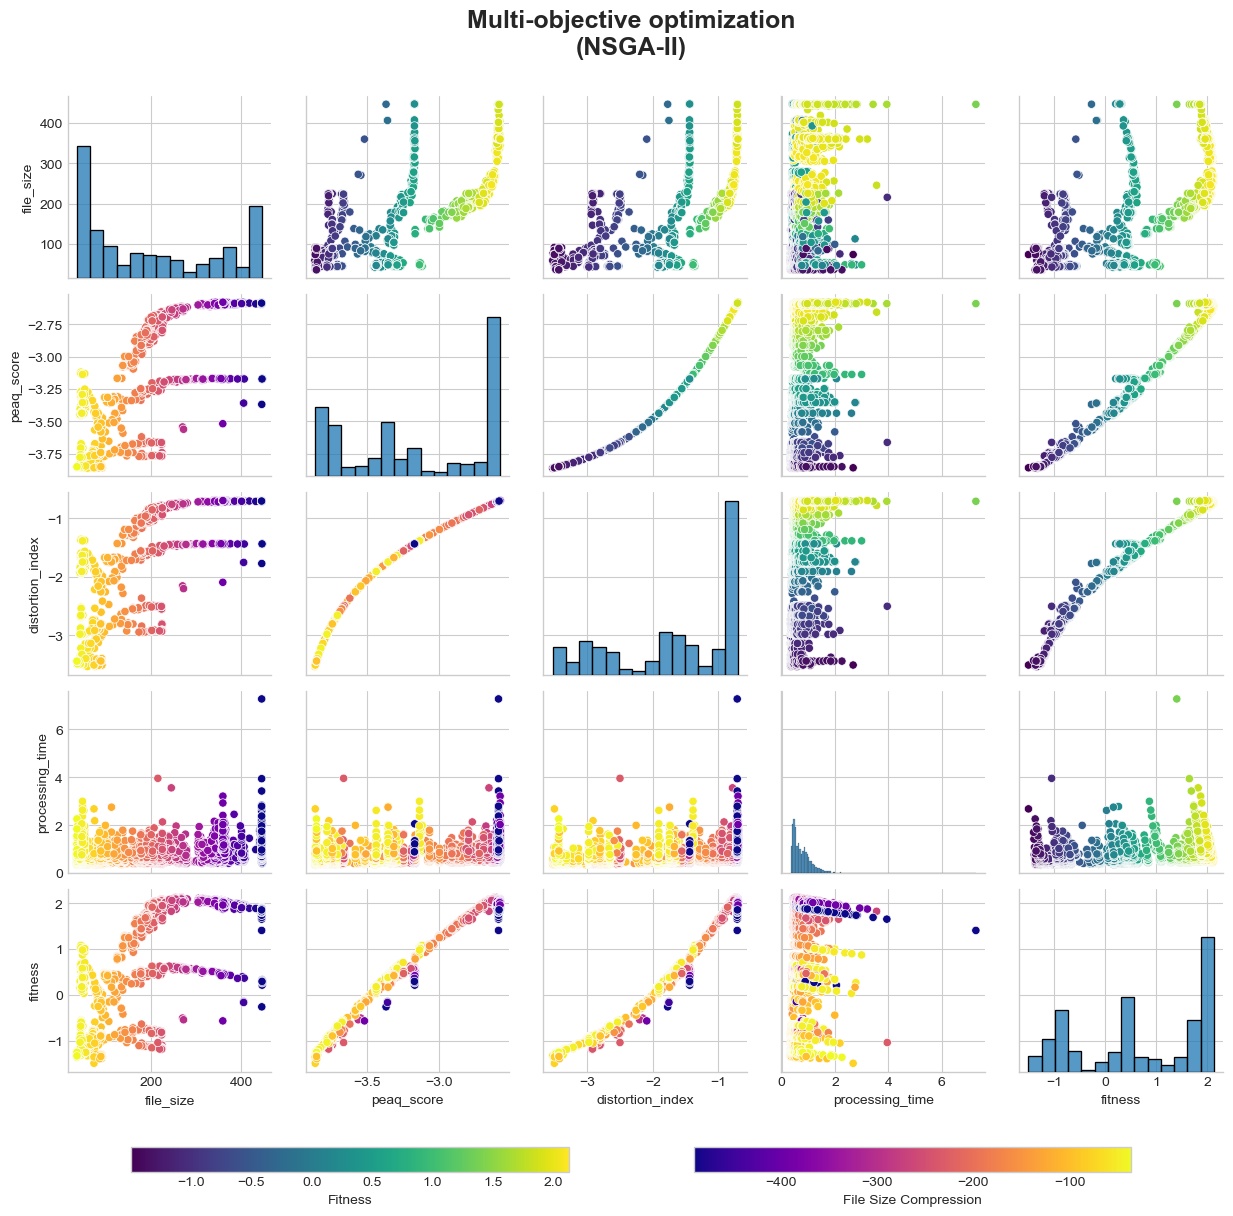

In [1235]:
# Select only the numerical fitness columns and fitness for the pair plot
fitness_cols = ['file_size', 'peaq_score', 'distortion_index', 'processing_time', 'fitness']

# Create a PairGrid instance
g = sns.PairGrid(df[fitness_cols])

# Map scatter plots to the upper and lower triangles, applying hue
# You can choose to map only upper, or only lower, or both
g.map_upper(sns.scatterplot, hue=df['fitness'], palette='viridis')
g.map_lower(sns.scatterplot, hue=-df['file_size'], palette='plasma')
# Map histograms to the diagonal, WITHOUT hue
g.map_diag(sns.histplot, edgecolor='black') # color='skyblue')

# Adjust the title position
plt.suptitle(f'Multi-objective optimization\n({algo})', y=1.05, fontsize=18, fontweight='bold')


# --- Custom Legend Creation (Colorbars) ---
# Adjust layout to make space for the legends at the bottom
# Increased bottom to make space for two horizontal colorbars
plt.subplots_adjust(bottom=0.20) # Adjust this value if you need more/less space

# Colorbar for the 'fitness' hue (upper triangle)
# Position: [left, bottom, width, height] in figure coordinates (0 to 1)
# Place them below the main plot area.
cbar_ax_fitness = g.fig.add_axes([0.1, 0.12, 0.35, 0.02]) # Left side, slightly higher
norm_fitness = plt.Normalize(df['fitness'].min(), df['fitness'].max())
sm_fitness = plt.cm.ScalarMappable(cmap="viridis", norm=norm_fitness)
sm_fitness.set_array(df['fitness']) # Important for mapping data to colors
g.fig.colorbar(sm_fitness, cax=cbar_ax_fitness, orientation='horizontal', label='Fitness')

# Colorbar for the '-file_size' hue (lower triangle)
cbar_ax_file_size = g.fig.add_axes([0.55, 0.12, 0.35, 0.02]) # Right side, same height as fitness
norm_file_size = plt.Normalize(-df['file_size'].min(), -df['file_size'].max())
sm_file_size = plt.cm.ScalarMappable(cmap="plasma", norm=norm_file_size)
sm_file_size.set_array(-df['file_size']) # Important for mapping data to colors
g.fig.colorbar(sm_file_size, cax=cbar_ax_file_size, orientation='horizontal', label='File Size Compression')

# Show the plot
plt.show()

#### Detailed graphs

peaq_score


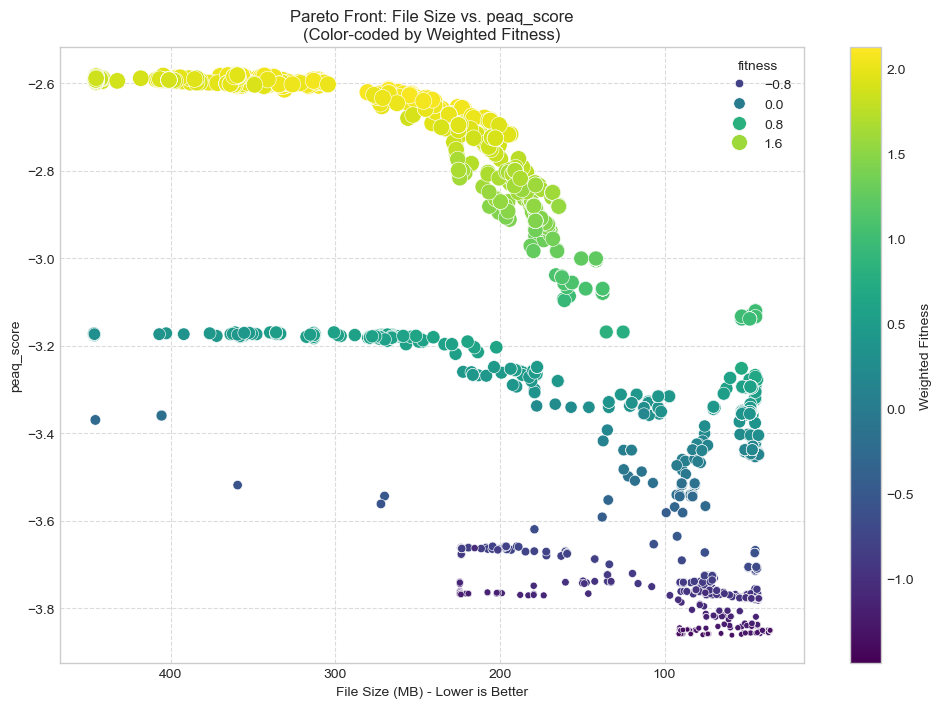

distortion_index


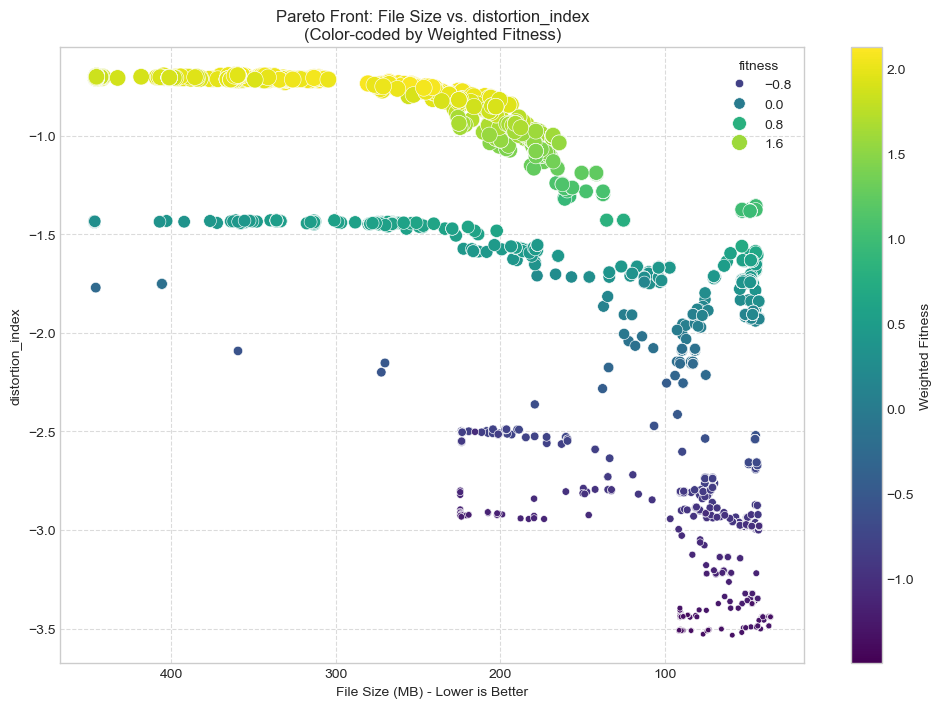

processing_time


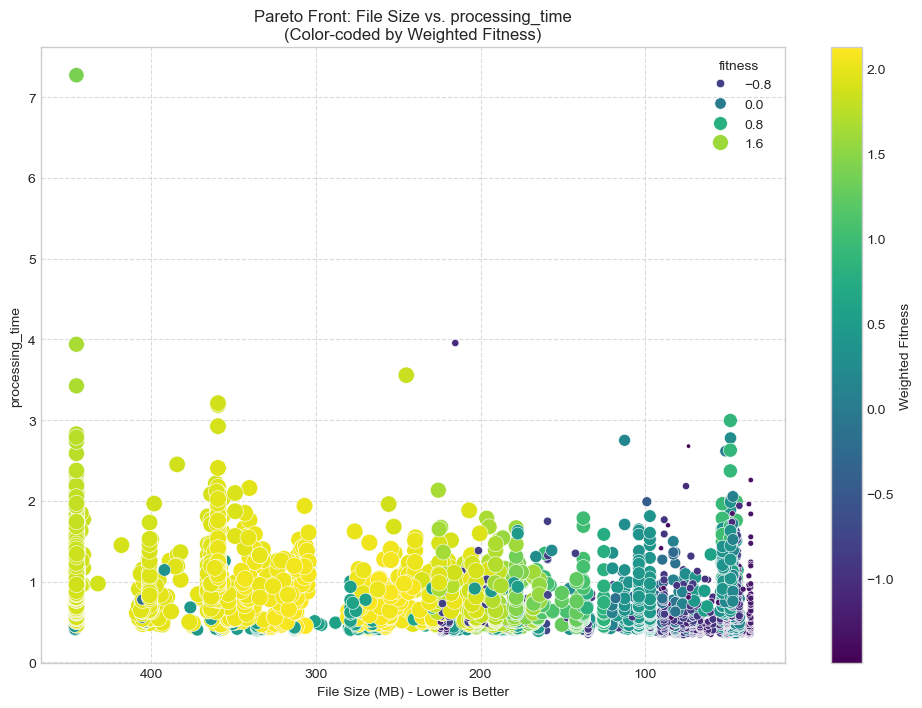

In [1236]:
data = df
data = data.reset_index()

for feature in ['peaq_score','distortion_index','processing_time']:
    print(feature)
    plt.figure(figsize=figsize)
    scatter = sns.scatterplot(
        data=data,
        x='file_size', 
        y=feature,
        hue='fitness', # Color points by weighted fitness
        size='fitness', # Size points by weighted fitness (optional, can be removed)
        sizes=(10, 150), # Adjust size range
        palette='viridis', # Choose a colormap
        #legend='full'
    )

    # Reverse x-axis if minimizing file_size makes lower values better
    plt.gca().invert_xaxis() # Assuming lower file_size is better

    plt.title(f'Pareto Front: File Size vs. {feature}\n(Color-coded by Weighted Fitness)')
    plt.xlabel('File Size (MB) - Lower is Better')
    plt.ylabel(f'{feature}')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Add a color bar
    norm = plt.Normalize(df['fitness'].min(), df['fitness'].max())
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=scatter.axes)
    cbar.set_label('Weighted Fitness')

    plt.show()

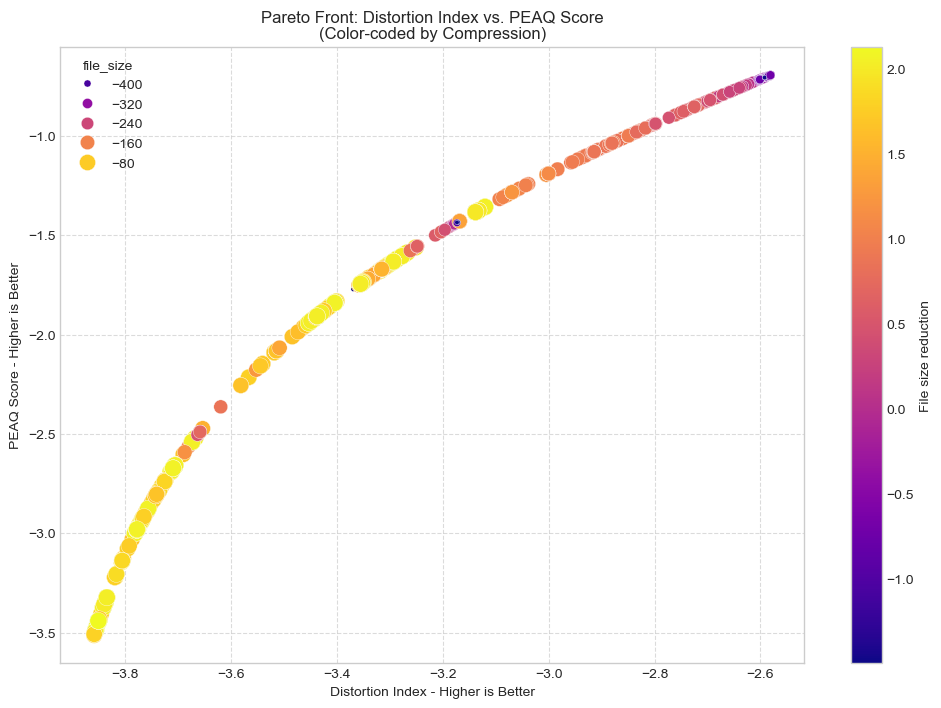

In [1237]:
# ['file_size', 'peaq_score','distortion_index','processing_time']
data_graph = sub_sample(data_full,0.5)
plt.figure(figsize=figsize)
scatter = sns.scatterplot(
    data=data_graph,
    x='peaq_score',
    y='distortion_index',
    hue=-data_graph['file_size'],  # Inverted hue mapping (lower is better)
    size=-data_graph['file_size'],  # Inverted hue mapping (lower is better)
    sizes=(10, 150),
    palette='plasma',
    #legend='full'
)

plt.title('Pareto Front: Distortion Index vs. PEAQ Score\n(Color-coded by Compression)')
plt.xlabel('Distortion Index - Higher is Better')
plt.ylabel('PEAQ Score - Higher is Better')
plt.grid(True, linestyle='--', alpha=0.7)

norm = plt.Normalize(df['fitness'].min(), df['fitness'].max())
sm = plt.cm.ScalarMappable(cmap="plasma", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=scatter.axes)
cbar.set_label('File size reduction')

plt.show()


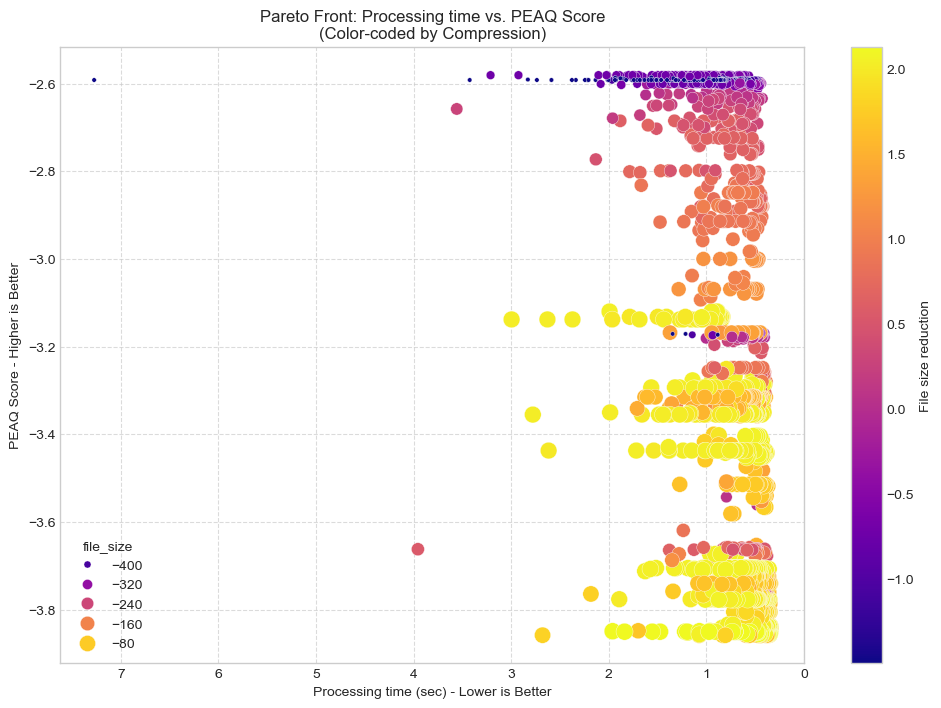

In [1238]:
# ['file_size', 'peaq_score','distortion_index','processing_time']
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=df,
    x='processing_time',
    y='peaq_score',
    hue=-data_graph['file_size'],  # Inverted hue mapping (lower is better)
    size=-data_graph['file_size'],  # Inverted hue mapping (lower is better)
    sizes=(10, 150),
    palette='plasma', # Choose a colormap
    #legend='full'
)

# Reverse x-axis if minimizing file_size makes lower values better
plt.gca().invert_xaxis() # Assuming lower file_size is better

plt.title('Pareto Front: Processing time vs. PEAQ Score\n(Color-coded by Compression)')
plt.xlabel('Processing time (sec) - Lower is Better')
plt.ylabel('PEAQ Score - Higher is Better')
plt.grid(True, linestyle='--', alpha=0.7)

# Add a color bar
norm = plt.Normalize(df['fitness'].min(), df['fitness'].max())
sm = plt.cm.ScalarMappable(cmap="plasma", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=scatter.axes)
cbar.set_label('File size reduction')

plt.show()

# Results: best individuals (HOF)

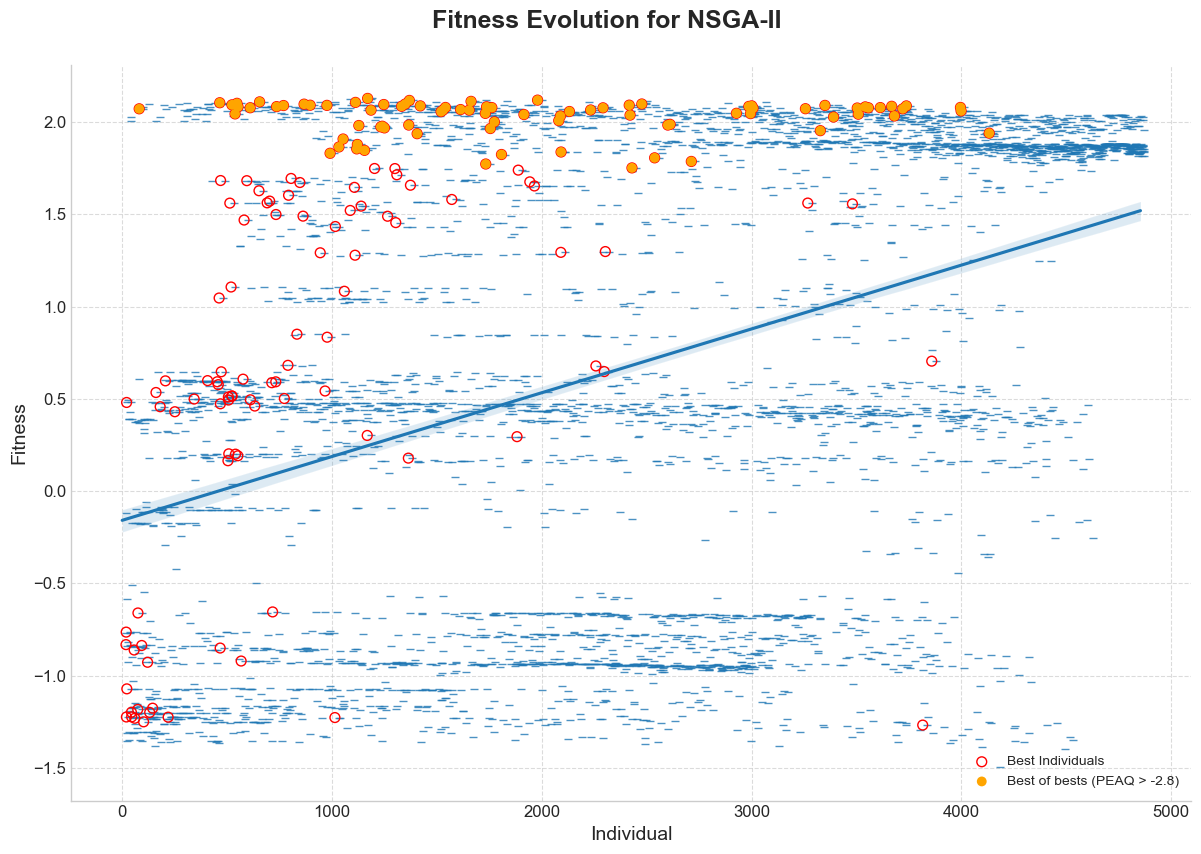

In [1239]:
data = df
data = data.reset_index()

# Plot the lmplot
g = sns.lmplot(
    data=data,
    x='index',
    y="fitness",
    markers=True,
    height=figsize[1],
    aspect=1.5,
)

g.set_axis_labels("Individual", "Fitness", fontsize=14)
g.fig.suptitle(f"Fitness Evolution for {algo}", fontsize=18, y=1.05, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

if Finished: 
    # Overlay red circle markers for 'best' individuals
    best_points = data[data['best']]
    plt.scatter(
        best_points['index'],
        best_points['fitness'],
        facecolors='none',
        edgecolors='red',
        marker='o',
        s=50, # Increased size for better visibility
        label='Best Individuals'
    )

    # Overlay green circle markers for 'best' individuals with peaq_score > -3
    peaq_threshold = -2.8
    best_points_green = data[(data['best']) & (data['peaq_score'] > peaq_threshold)]
    plt.scatter(
        best_points_green['index'],
        best_points_green['fitness'],
        facecolors='orange',
        edgecolors='none',
        marker='o',
        s=50, # Increased size for better visibility
        label=f'Best of bests (PEAQ > {peaq_threshold})'
    )

plt.legend(loc='lower right') # Moved legend to avoid conflict with annotation

plt.show()

In [1240]:
from scipy import stats

print(f"{algo} ALGORITHM")
# Calculate the slope and intercept using scipy.stats.linregress
slope, intercept, r_value, p_value, std_err = stats.linregress(data['index'], data['fitness'])

# Calcular el valor 'y' para len(df)
y_final = slope * len(df) + intercept

def improves(initial, final):
    if initial == 0: return '∞' #float('inf')
    improvement = abs(final/initial)
    if round(improvement) < 1:
        return f'{round(improvement,2)}x'
    else:
        return f'{round(improvement)}x'

print(f"Pendiente de la curva de tendencia: {slope:.4f}")
print(f"Coeficiente de correlación (R): {r_value:.4f}\n")
print(f"Fitness medio incial: {intercept:.4f}")
print(f"Fitness medio final: {y_final:.4f}")
print(f'Representa una mejora de {improves(intercept,y_final)}')

NSGA-II ALGORITHM
Pendiente de la curva de tendencia: 0.0003
Coeficiente de correlación (R): 0.4018

Fitness medio incial: -0.1581
Fitness medio final: 1.5201
Representa una mejora de 10x


---

In [1241]:
if not Finished:
    raise RuntimeError("Execution stopped: Results file not found or process not finished.")

In [1242]:
data = df_res
data = data.reset_index()

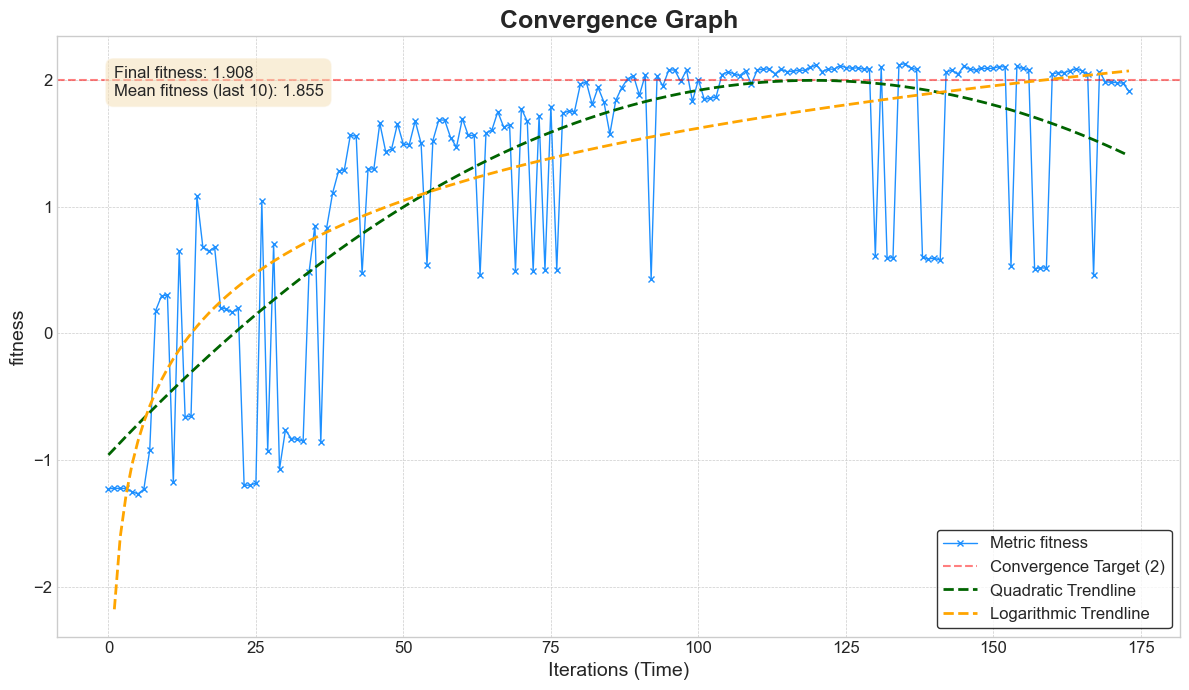

In [1243]:
# --- Create the Convergence Graph ---

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the convergence data
ax.plot(data['index'], data['fitness'], label='Metric fitness', color='dodgerblue', marker='x', markersize=5, linestyle='-', linewidth=1, alpha=1)

# Add a horizontal line for the convergence target
ax.axhline(y=convergence_target, color='r', linestyle='--', label=f'Convergence Target ({convergence_target})', alpha=0.5)

# --- Add Quadratic Trendline ---
# Fit a 2nd degree polynomial (quadratic) to the data
valid_indices = data['index'].values
valid_fitness = data['fitness'].values
coefficients = np.polyfit(valid_indices, valid_fitness, 2) # 2 for quadratic
polynomial = np.poly1d(coefficients)
trendline_y = polynomial(valid_indices) # y-values for the trendline 
ax.plot(valid_indices, trendline_y, label='Quadratic Trendline', color='darkgreen', linestyle='--', linewidth=2)

# --- Add Logarithmic Trendline ---
# Fit a linear polynomial to log(x) and y to get coefficients for a logarithmic trendline
# A logarithmic trendline is of the form y = A * log(x) + B
# We perform a linear fit on y vs. log(x)
positive_indices_mask = data['index'] > 0 # Ensure only finite and positive values are used for logarithmic fitting
filtered_indices = data['index'][positive_indices_mask].values
filtered_fitness = data['fitness'][positive_indices_mask].values
# Only attempt to fit if there are enough data points after filtering
if len(filtered_indices) > 1:
    coefficients_log = np.polyfit(np.log(filtered_indices), filtered_fitness, 1) # 1 for linear fit
    poly_log = np.poly1d(coefficients_log)
    trendline_y_log = poly_log(np.log(filtered_indices)) # y-values for the trendline 
    ax.plot(filtered_indices, trendline_y_log, label='Logarithmic Trendline', color='orange', linestyle='--', linewidth=2)
else:
    print("Warning: Not enough positive data points to fit a logarithmic trendline.")

# --- Customize the plot ---
ax.set_title('Convergence Graph', fontsize=18, fontweight='bold')
ax.set_xlabel('Iterations (Time)', fontsize=14)
ax.set_ylabel('fitness', fontsize=14)
ax.legend(fontsize=12, frameon=True, facecolor='white', edgecolor='black') 
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Add a text box with some stats
stats_text = (f"Final fitness: {data['fitness'].iloc[-1]:.3f}\n"
            f"Mean fitness (last 10): {data['fitness'].tail(10).mean():.3f}")
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Show the plot
plt.tight_layout()
plt.show()


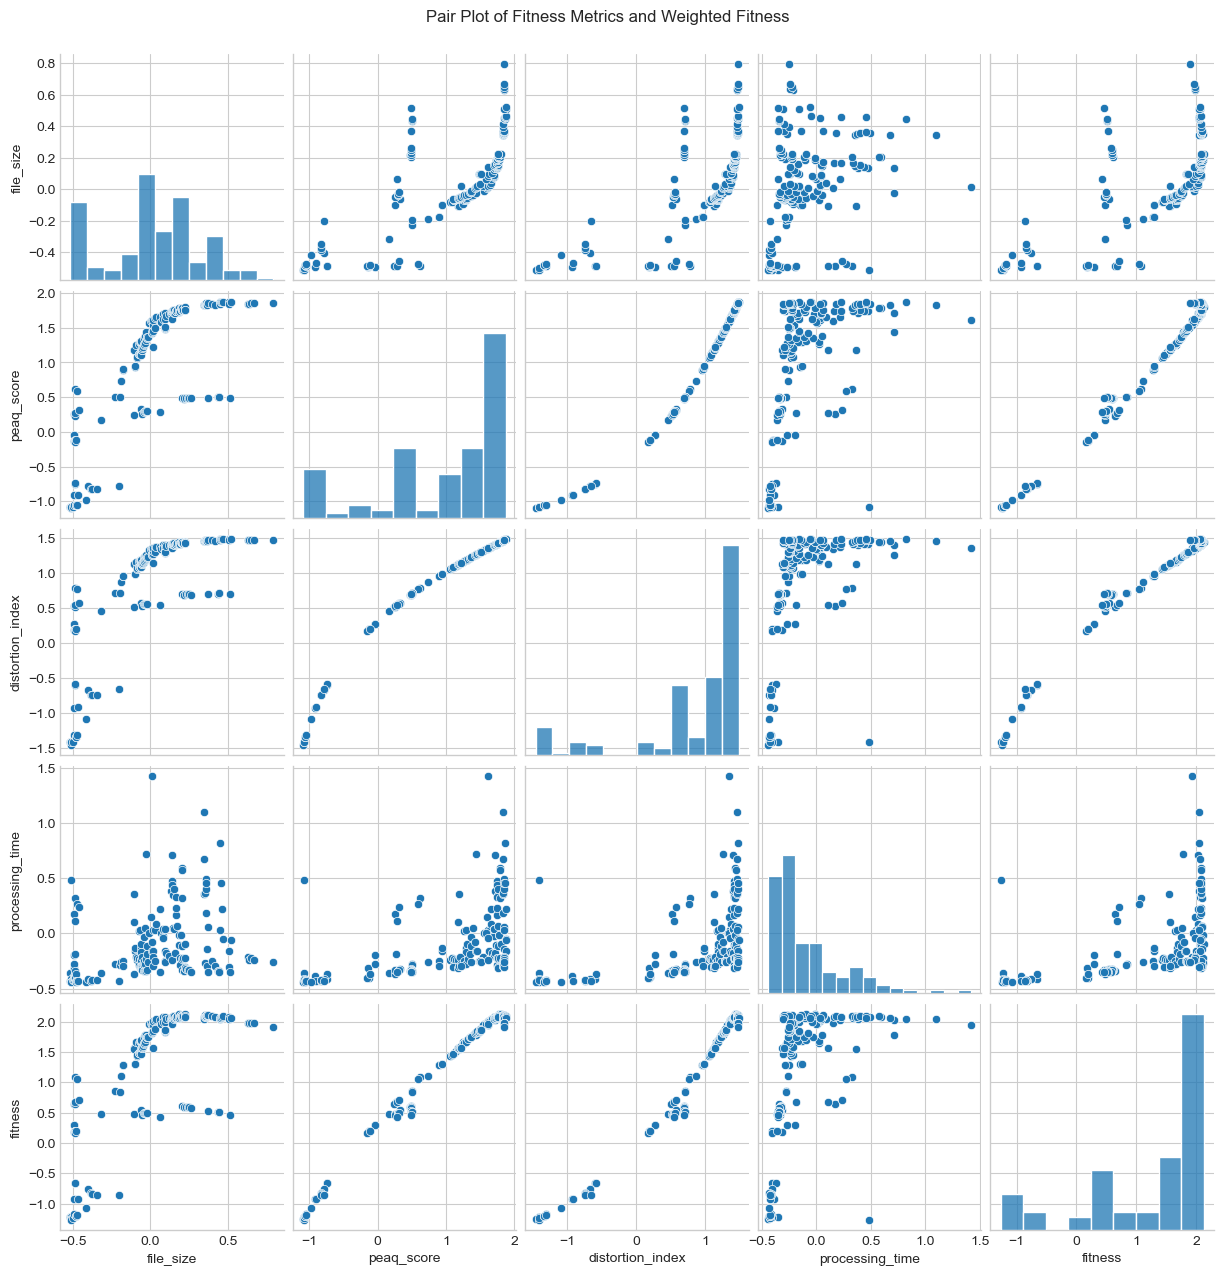

In [1244]:
# Select only the numerical fitness columns and fitness for the pair plot
fitness_cols = ['file_size', 'peaq_score', 'distortion_index', 'processing_time', 'fitness']
sns.pairplot(data[fitness_cols])
plt.suptitle('Pair Plot of Fitness Metrics and Weighted Fitness', y=1.02) # Adjust title position
plt.show()

# Best params analysis

### By Fitness

In [1245]:
threshold = 1.5 # Set threshold for optimal results filtering
df_opt = df[df['fitness'] > threshold]
df_opt

,params,file_size,peaq_score,distortion_index,processing_time,fitness,best
23,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",374.895508,-2.598,-0.713,0.453387,2.005343,False
24,"{'ar': '44100', 'sample_fmt': 's32p', 'compres...",370.096680,-2.583,-0.697,0.794408,2.027791,False
81,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",356.811523,-2.582,-0.695,0.527517,2.071677,True
82,"{'ar': '44100', 'sample_fmt': 'fltp', 'compres...",312.220703,-2.594,-0.709,0.953638,2.078957,False
107,"{'ar': '44100', 'sample_fmt': 's32p', 'compres...",312.220703,-2.596,-0.710,0.609578,2.099412,False
...,...,...,...,...,...,...,...
4850,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",445.613281,-2.592,-0.706,1.402674,1.838524,False
4851,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",445.613281,-2.592,-0.706,1.743312,1.813347,False
4852,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",445.613281,-2.592,-0.706,1.309196,1.845433,False
4853,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",359.584961,-2.581,-0.694,2.023823,1.959300,False


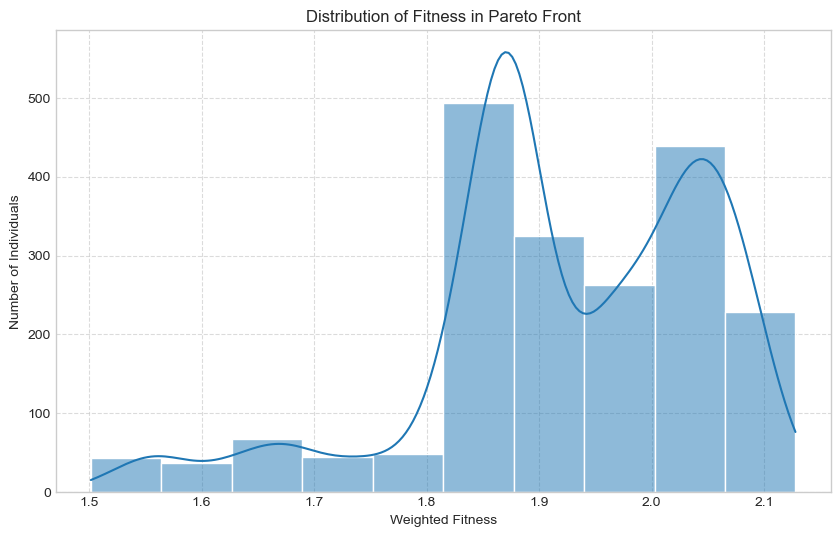

In [1246]:
plt.figure(figsize=(10, 6))
sns.histplot(df_opt['fitness'], kde=True, bins=10)
plt.title('Distribution of Fitness in Pareto Front')
plt.xlabel('Weighted Fitness')
plt.ylabel('Number of Individuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

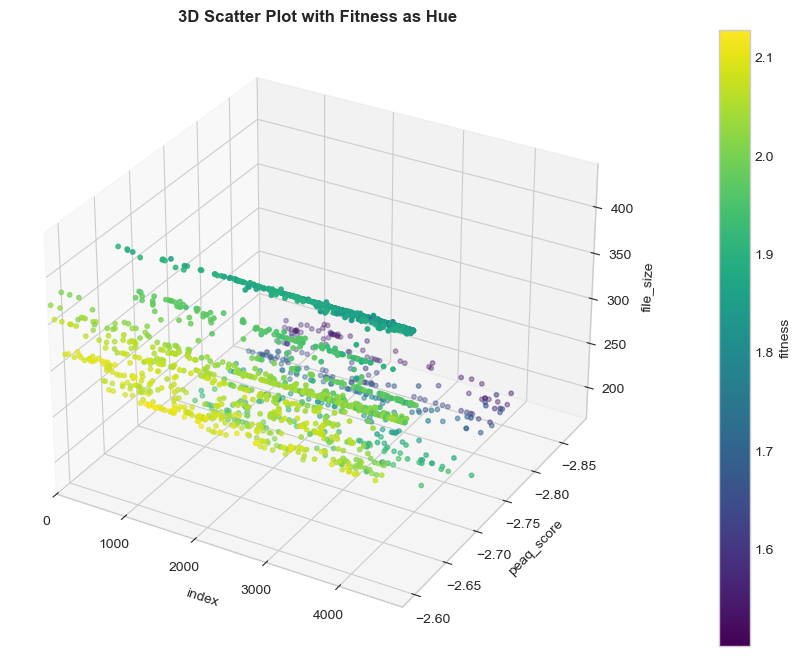

In [1247]:
num_points = len(df)

# Set seaborn style for better aesthetics
sns.set_style("whitegrid")

# Create a 3D figure
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D scatter plot with 'fitness' determining the color
# 'c' parameter is used to map numerical values to colors, and 'cmap' specifies the colormap
scatter = ax.scatter(
    df_opt.index,         # X-axis
    df_opt['peaq_score'], # Y-axis
    df_opt['file_size'],  # Z-axis (using df_optFrame index as requested)
    c=df_opt['fitness'],  # Color based on 'fitness' values
    cmap='viridis',   # Colormap (you can try others like 'plasma', 'magma', 'cividis')
    s=10              # Size of the scatter points
)

# Set labels for each axis
ax.set_xlabel('index')
ax.set_ylabel('peaq_score')
ax.set_zlabel('file_size')

# Set the limits for each axis
ax.set_xlim(0, num_points) # Z-axis limit set to the number of df_opt points
ax.set_ylim(df_opt['peaq_score'].max(), df_opt['peaq_score'].min())
ax.set_zlim(df_opt['file_size'].min(), df_opt['file_size'].max())

# Set the title of the plot
ax.set_title('3D Scatter Plot with Fitness as Hue', fontsize=12, fontweight='bold')

# Add a color bar to explain the 'fitness' color mapping
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('fitness')

# Display the plot
plt.show()

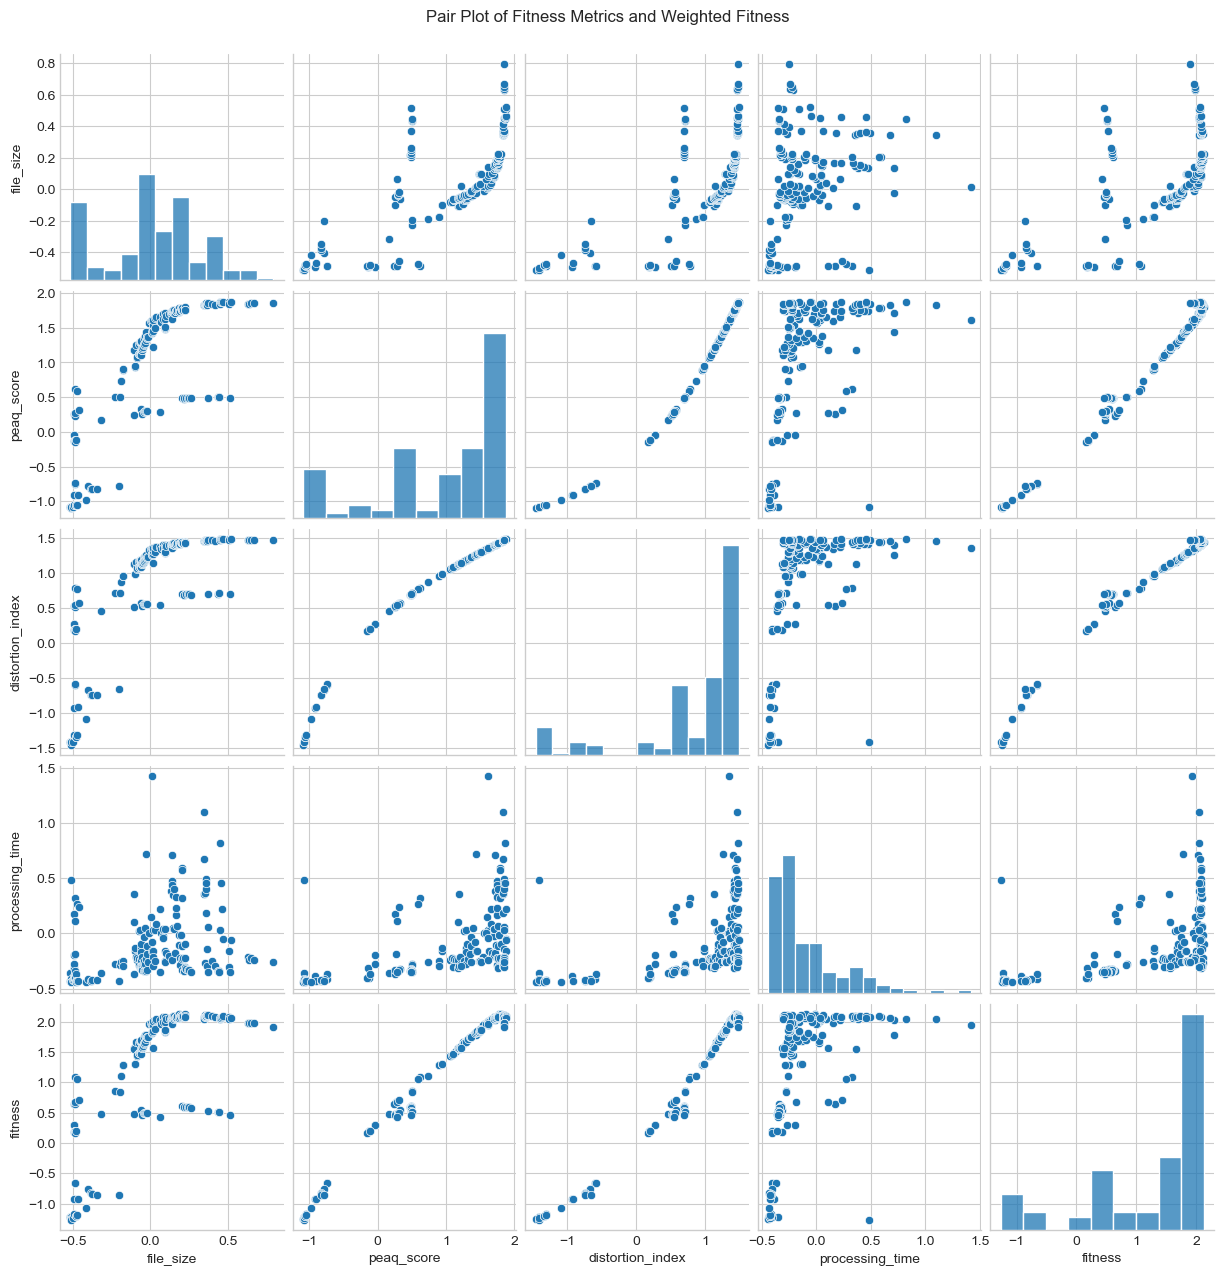

In [1248]:
# Select only the numerical fitness columns and fitness for the pair plot
fitness_cols = ['file_size', 'peaq_score', 'distortion_index', 'processing_time', 'fitness']
sns.pairplot(data[fitness_cols])
plt.suptitle('Pair Plot of Fitness Metrics and Weighted Fitness', y=1.02) # Adjust title position
plt.show()

### By PEAQ

In [1249]:
threshold = -2.8 # Set threshold for optimal results filtering
df_opt = df[(df['peaq_score'] > threshold) & (df['best']==True)]
n_win = len(df_opt)
df_opt

,params,file_size,peaq_score,distortion_index,processing_time,fitness,best
81,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",356.811523,-2.582,-0.695,0.527517,2.071677,True
465,"{'ar': '44100', 'sample_fmt': 's32p', 'compres...",312.220703,-2.596,-0.710,0.540015,2.104554,True
523,"{'ar': '44100', 'sample_fmt': 's32p', 'compres...",267.627930,-2.630,-0.747,0.428801,2.093039,True
538,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",356.811523,-2.595,-0.709,0.430878,2.044114,True
547,"{'ar': '44100', 'sample_fmt': 's32p', 'compres...",312.220703,-2.600,-0.715,0.436215,2.101329,True
...,...,...,...,...,...,...,...
3721,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",239.921875,-2.640,-0.758,0.954504,2.071623,True
3738,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",243.781250,-2.634,-0.752,0.873866,2.087298,True
3996,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",241.242188,-2.637,-0.755,0.932736,2.079062,True
3999,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",304.536133,-2.602,-0.716,1.090981,2.060220,True


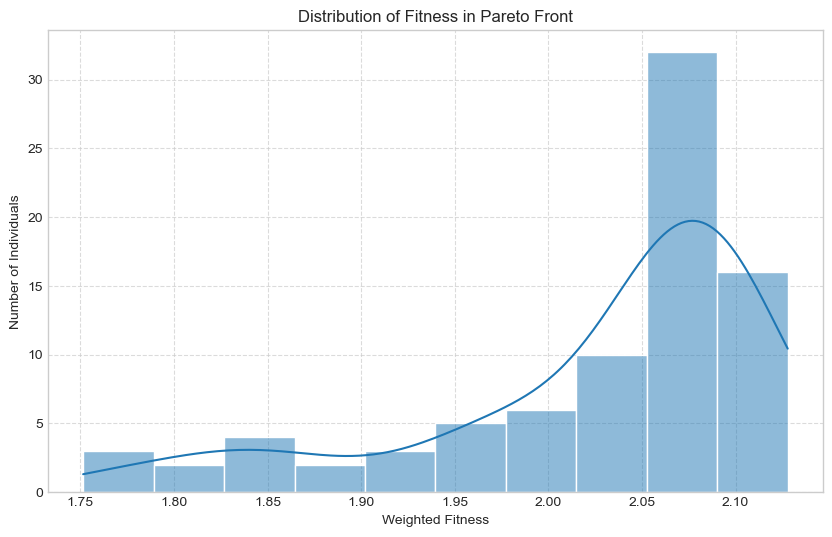

In [1250]:
plt.figure(figsize=(10, 6))
sns.histplot(df_opt['fitness'], kde=True, bins=10)
plt.title('Distribution of Fitness in Pareto Front')
plt.xlabel('Weighted Fitness')
plt.ylabel('Number of Individuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

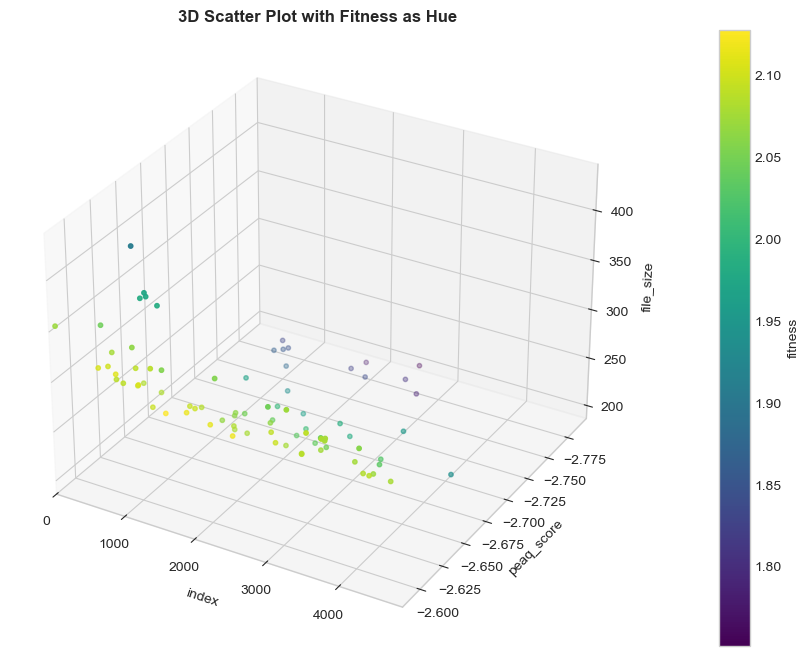

In [1251]:
num_points = len(df)

# Set seaborn style for better aesthetics
sns.set_style("whitegrid")

# Create a 3D figure
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D scatter plot with 'fitness' determining the color
# 'c' parameter is used to map numerical values to colors, and 'cmap' specifies the colormap
scatter = ax.scatter(
    df_opt.index,         # X-axis
    df_opt['peaq_score'], # Y-axis
    df_opt['file_size'],  # Z-axis (using df_optFrame index as requested)
    c=df_opt['fitness'],  # Color based on 'fitness' values
    cmap='viridis',   # Colormap (you can try others like 'plasma', 'magma', 'cividis')
    s=10              # Size of the scatter points
)

# Set labels for each axis
ax.set_xlabel('index')
ax.set_ylabel('peaq_score')
ax.set_zlabel('file_size')

# Set the limits for each axis
ax.set_xlim(0, num_points) # Z-axis limit set to the number of df_opt points
ax.set_ylim(df_opt['peaq_score'].max(), df_opt['peaq_score'].min())
ax.set_zlim(df_opt['file_size'].min(), df_opt['file_size'].max())

# Set the title of the plot
ax.set_title('3D Scatter Plot with Fitness as Hue', fontsize=12, fontweight='bold')

# Add a color bar to explain the 'fitness' color mapping
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('fitness')

# Display the plot
plt.show()

In [1252]:
data = df_opt.reset_index()

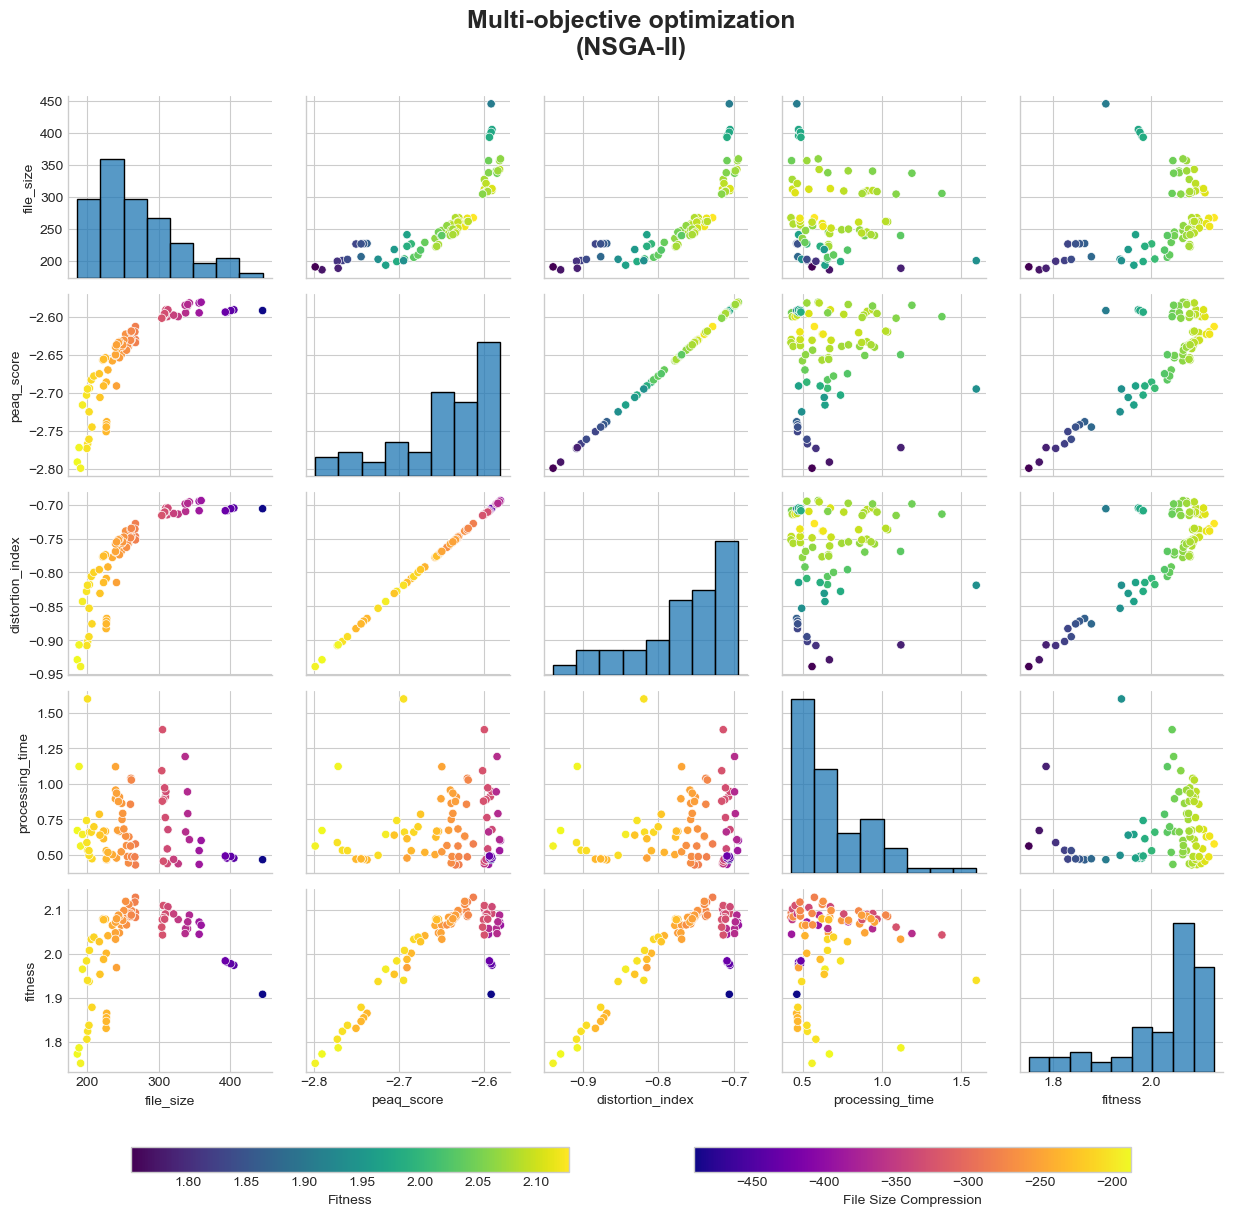

In [1253]:
# Select only the numerical fitness columns and fitness for the pair plot
fitness_cols = ['file_size', 'peaq_score', 'distortion_index', 'processing_time', 'fitness']

# Create a PairGrid instance
g = sns.PairGrid(data[fitness_cols])

# Map scatter plots to the upper and lower triangles, applying hue
# You can choose to map only upper, or only lower, or both
g.map_upper(sns.scatterplot, hue=data['fitness'], palette='viridis')
g.map_lower(sns.scatterplot, hue=-data['file_size'], palette='plasma')
# Map histograms to the diagonal, WITHOUT hue
g.map_diag(sns.histplot, edgecolor='black') # color='skyblue')

# Adjust the title position
plt.suptitle(f'Multi-objective optimization\n({algo})', y=1.05, fontsize=18, fontweight='bold')


# --- Custom Legend Creation (Colorbars) ---
# Adjust layout to make space for the legends at the bottom
# Increased bottom to make space for two horizontal colorbars
plt.subplots_adjust(bottom=0.20) # Adjust this value if you need more/less space

# Colorbar for the 'fitness' hue (upper triangle)
# Position: [left, bottom, width, height] in figure coordinates (0 to 1)
# Place them below the main plot area.
cbar_ax_fitness = g.fig.add_axes([0.1, 0.12, 0.35, 0.02]) # Left side, slightly higher
norm_fitness = plt.Normalize(data['fitness'].min(), data['fitness'].max())
sm_fitness = plt.cm.ScalarMappable(cmap="viridis", norm=norm_fitness)
sm_fitness.set_array(data['fitness']) # Important for mapping data to colors
g.fig.colorbar(sm_fitness, cax=cbar_ax_fitness, orientation='horizontal', label='Fitness')

# Colorbar for the '-file_size' hue (lower triangle)
cbar_ax_file_size = g.fig.add_axes([0.55, 0.12, 0.35, 0.02]) # Right side, same height as fitness
norm_file_size = plt.Normalize(-data['file_size'].min(), -data['file_size'].max())
sm_file_size = plt.cm.ScalarMappable(cmap="plasma", norm=norm_file_size)
sm_file_size.set_array(-data['file_size']) # Important for mapping data to colors
g.fig.colorbar(sm_file_size, cax=cbar_ax_file_size, orientation='horizontal', label='File Size Compression')

# Show the plot
plt.show()

### Top 5 individuals

Los 5 mejores individuos según la condición establecida (PEAQ > -2.8)

In [1254]:
df_opt.sort_values(by=['fitness','file_size'],ascending=False).head(5)

,params,file_size,peaq_score,distortion_index,processing_time,fitness,best
1170,"{'ar': '44100', 'sample_fmt': 's32p', 'compres...",267.627930,-2.613,-0.728,0.574741,2.127855,True
1980,"{'ar': '44100', 'sample_fmt': 's32p', 'compres...",254.042969,-2.623,-0.739,0.629851,2.118690,True
1369,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",266.853516,-2.620,-0.736,0.483870,2.116974,True
1663,"{'ar': '44100', 'sample_fmt': 's32p', 'compres...",258.514648,-2.623,-0.739,0.625046,2.111909,True
655,"{'ar': '44100', 'sample_fmt': 's32p', 'compres...",306.680664,-2.600,-0.714,0.453298,2.109222,True


In [1257]:
print(f"De los {n_hof} individuos ganadores ({n_ind} explorados), se seleccionaron {n_win} óptimos para el fin deseado ({round(n_win/n_hof*100,1)}%)")

De los 174 individuos ganadores (4855 explorados), se seleccionaron 83 óptimos para el fin deseado (47.7%)


In [1258]:
df_opt.describe()

,file_size,peaq_score,distortion_index,processing_time,fitness
count,83.000000,83.000000,83.000000,83.000000,83.000000
mean,267.831302,-2.648096,-0.767831,0.680728,2.025359
std,58.027823,0.057189,0.063723,0.235585,0.092853
min,186.280273,-2.799000,-0.939000,0.426985,1.751456
25%,226.705078,-2.680500,-0.803000,0.486801,1.983672
50%,254.042969,-2.634000,-0.752000,0.625046,2.065288
75%,308.986816,-2.599000,-0.713500,0.822426,2.086269
max,445.613281,-2.581000,-0.694000,1.597123,2.127855


### Optimal individual

In [1255]:
df_opt.sort_values(by=['fitness','file_size'],ascending=False).iloc[0]

params              {'ar': '44100', 'sample_fmt': 's32p', 'compres...
file_size                                                   267.62793
peaq_score                                                     -2.613
distortion_index                                               -0.728
processing_time                                              0.574741
fitness                                                      2.127855
best                                                             True
Name: 1170, dtype: object

In [ ]:
df_opt.sort_values(by=['fitness','file_size'],ascending=False).iloc[0]['params']

"{'ar': '44100', 'sample_fmt': 's32p', 'compression_level': '4', 'reservoir': '0', 'b:a': '190k'}"

---

# Clustering

In [1262]:
# --- 1. Data Preparation  ---
df_=df.copy()

# Convert 'params' string to dictionary
df_['params_dict'] = df_['params'].apply(ast.literal_eval)

df_.sample()

,params,file_size,peaq_score,distortion_index,processing_time,fitness,best,params_dict
1830,"{'ar': '44100', 'sample_fmt': 's32p', 'compres...",97.147461,-3.314,-1.668,0.511765,0.474722,False,"{'ar': '44100', 'sample_fmt': 's32p', 'compres..."


In [1263]:
# Extract params from dict and convert them into features
for idx, row in df_.iterrows():
    for param in row['params_dict']:
        df_.at[idx, param] = row['params_dict'][param]

In [ ]:
# --- 2.  Feature Engineering ---

# Extract features from 'params_dict'
# Data type conversion
df_['abr'] = df_['abr'].astype(bool)
df_['reservoir'] = df_['reservoir'].astype(bool)
df_['ar'] = df_['ar'].astype(int)
# NaN handling
df_['aq'] = df_['aq'].fillna(-1).astype(int)
df_['compression_level'] = df_['compression_level'].fillna(-1).astype(int)
# 'b:a' also needs string 'k' removal
df_['b:a'] = df_['b:a'].apply(lambda x: int(x.replace('k', '')) if isinstance(x, str) and 'k' in x else x).fillna(-1).astype(int)

# One-hot encode 'sample_fmt' and join to df_
sample_fmt_dummies = pd.get_dummies(df_['sample_fmt'], prefix='sample_fmt')
df_ = pd.concat([df_, sample_fmt_dummies], axis=1)

# Select features for clustering
# # We'll include all numerical columns and the newly extracted ones
#numerical_features = ['file_size', 'peaq_score', 'distortion_index', 'processing_time', 'fitness', 'aq','ar','b:a', 'compression_level']
numerical_features = ['file_size', 'peaq_score', 'distortion_index', 'processing_time', 'aq','ar','b:a', 'compression_level']
#categorical_features = ['best', 'abr', 'reservoir'] + list(sample_fmt_dummies.columns)
categorical_features = ['reservoir'] + list(sample_fmt_dummies.columns)

# # # Combine selected features into a new DataFrame for processing
features_df = df_[numerical_features + categorical_features].copy()
#features_df = df_[numerical_features].copy()

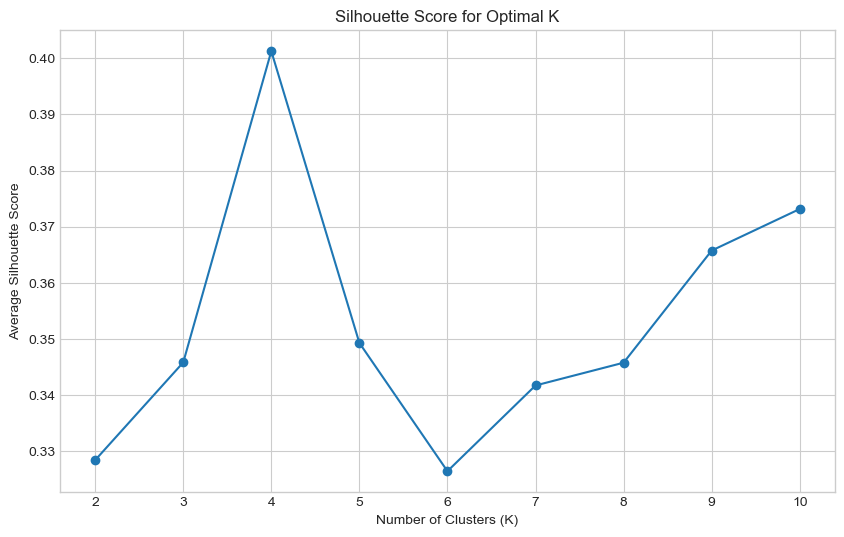


--- Interpreting the Silhouette Plot ---
The optimal K is usually the one that yields the highest average Silhouette Score.
Silhouette scores for K=[2, 3, 4, 5, 6, 7, 8, 9, 10]: [np.float64(0.3284574326073701), np.float64(0.3458476889837837), np.float64(0.4012457911786981), np.float64(0.3493136388727215), np.float64(0.32648767898364706), np.float64(0.34174424540876563), np.float64(0.34579591944103766), np.float64(0.36575409481173016), np.float64(0.3731532085786438)]


In [1265]:
# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df)

# --- Reuse scaled_features from the Elbow Method example ---

# Apply Silhouette Score for a range of K values
silhouette_scores = []
# For Silhouette Score, k must be >= 2
k_range_silhouette = range(2, min(11, scaled_features.shape[0]))

for i in k_range_silhouette:
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, cluster_labels)
    silhouette_scores.append(score)

# Plot the Silhouette Score graph
plt.figure(figsize=(10, 6))
plt.plot(k_range_silhouette, silhouette_scores, marker='o', linestyle='-')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.xticks(k_range_silhouette)
plt.grid(True)
plt.show()

print("\n--- Interpreting the Silhouette Plot ---")
print("The optimal K is usually the one that yields the highest average Silhouette Score.")
print(f"Silhouette scores for K={list(k_range_silhouette)}: {silhouette_scores}")

In [1266]:
n_clusters = k_range_silhouette[np.argmax(silhouette_scores)]
print(f"Silhouette score showed that {n_clusters} is the optimal number of clusters.")

Silhouette score showed that 4 is the optimal number of clusters.


In [1267]:
# from sklearn.preprocessing import OneHotEncoder

# # Preprocessing pipeline
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numerical_features),
#         ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
#     ])

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numerical_features)
#     ])

# Apply preprocessing
#processed_features = preprocessor.fit_transform(features_df)
processed_features = features_df
print(f"\nShape of processed features for t-SNE: {processed_features.shape}")

# --- 3. Apply t-SNE ---
# n_components=2 for 2D visualization
# perplexity is a key parameter, often tested in ranges like 5-50
# random_state for reproducibility
tsne = TSNE(n_components=2, perplexity=min(5, processed_features.shape[0] - 1), random_state=42) # Adjust perplexity for small dataset
tsne_results = tsne.fit_transform(processed_features)

df_tsne = pd.DataFrame(data=tsne_results, columns=['tsne_component_1', 'tsne_component_2'])

# --- 4. Apply Clustering (e.g., K-Means) to t-SNE results ---
# In a real scenario, you'd determine the optimal 'k' using methods like Elbow/Silhouette.
# For demonstration, let's assume 3 clusters for this dummy data.
#n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(tsne_results)
df_tsne['cluster'] = clusters

print(f"\nClusters found (k={n_clusters}):")
print(df_tsne['cluster'].value_counts())


Shape of processed features for t-SNE: (4855, 12)

Clusters found (k=4):
cluster
2    1283
1    1246
0    1202
3    1124
Name: count, dtype: int64


In [1268]:
# Optional: Add original 'best' column to t-SNE for comparison if relevant
df_tsne['best'] = df['best'].values
df_tsne[df_tsne['best']==True]

,tsne_component_1,tsne_component_2,cluster,best
18,-44.300926,18.589827,3,True
19,-30.806316,-45.020676,1,True
20,-94.726410,48.364605,3,True
21,110.668961,-28.793163,0,True
22,-52.817394,-32.839855,3,True
...,...,...,...,...
3816,-78.458046,42.588543,3,True
3859,-10.003730,-113.516312,1,True
3996,12.720958,-15.512508,1,True
3999,20.027866,10.834851,0,True


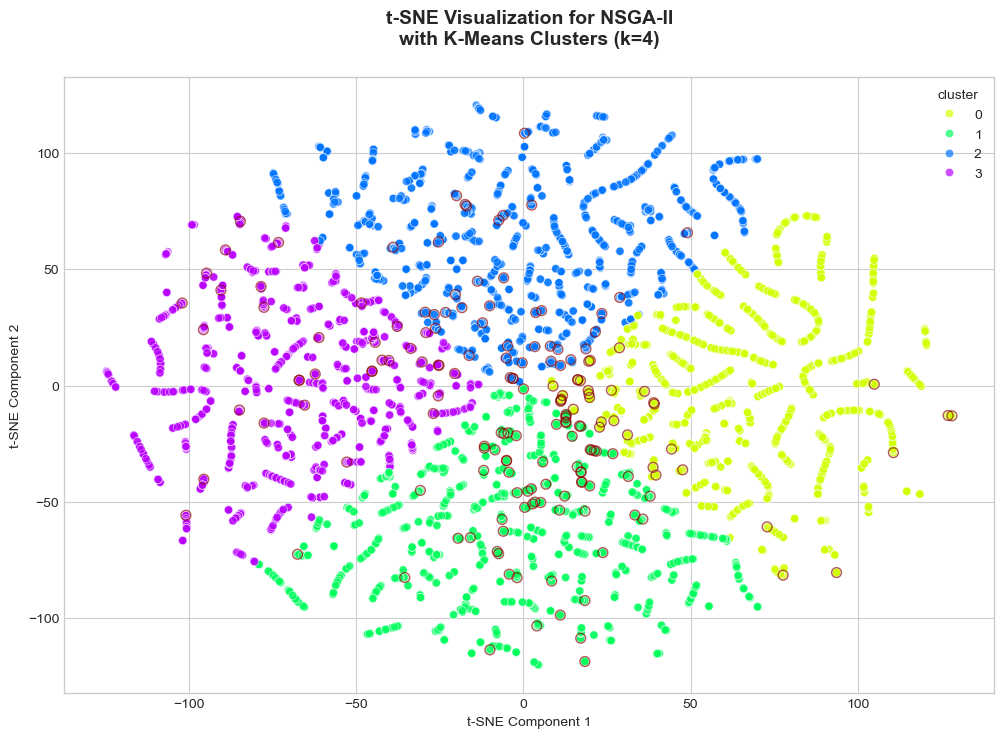

In [1269]:
# --- 5. Graph the Clusters ---
plt.figure(figsize=figsize)
sns.scatterplot(
    x="tsne_component_1", y="tsne_component_2",
    hue="cluster",
    palette=sns.color_palette("hsv", n_clusters), # Use a distinct color palette
    data=df_tsne,
    legend="full",
    alpha=0.7
)

# Overlay original 'best' points as orange circles with no fill
best_points = df_tsne[df_tsne['best']]
plt.scatter(
    best_points['tsne_component_1'],
    best_points['tsne_component_2'],
    facecolors='none',
    edgecolors='darkred',
    marker='o',
    s=50,
    linewidths=1,
    alpha=0.65,
    label='Best (original)'
)
plt.title(f't-SNE Visualization for {algo}\nwith K-Means Clusters (k={n_clusters})', fontsize=14, fontweight='bold', y=1.04)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

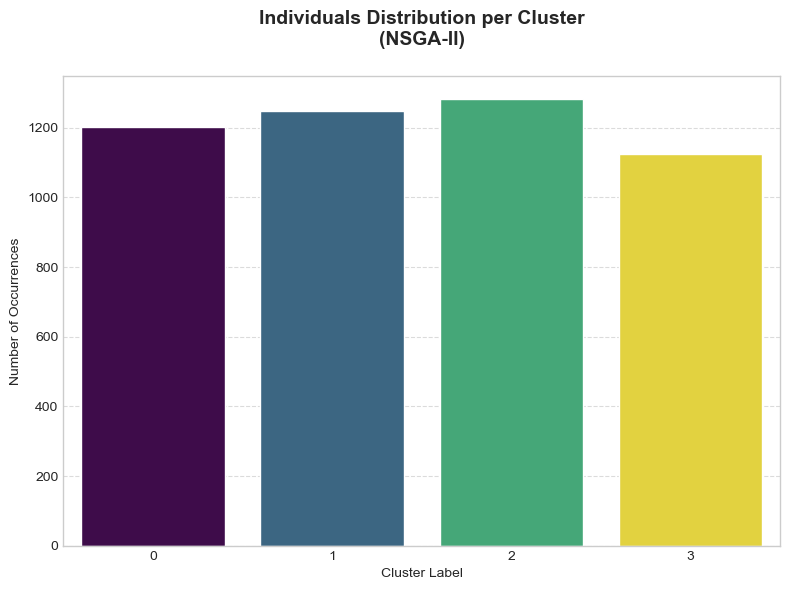

In [1270]:
# --- Plot the distribution of individuals into 'cluster' for the original data ---
plt.figure(figsize=(8, 6))
sns.countplot(x='cluster', data=df_tsne, palette='viridis', hue='cluster', legend=False)
plt.title(f'Individuals Distribution per Cluster\n({algo})', fontsize=14, fontweight='bold', y=1.05)
plt.xlabel('Cluster Label')
plt.ylabel('Number of Occurrences')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [1271]:
df_tsne = df_tsne.reset_index()
df = df.reset_index()

In [1272]:
if df_res is not None:
	merged = pd.merge(df, df_tsne, how='left', on='index')
	# If you want to keep only 'best_x' and rename it to 'best' in merged:
	merged = merged.drop(columns=['best_y'])
	merged = merged.rename(columns={'best_x': 'best'})
	display(merged)
else:
	print("df_res is None. Cannot perform merge.")

,index,params,file_size,peaq_score,distortion_index,processing_time,fitness,best,tsne_component_1,tsne_component_2,cluster
0,0,"{'ar': '48000', 'sample_fmt': 's16p', 'compres...",179.164062,-3.669,-2.525,0.734796,-0.770109,False,49.119942,-12.687407,0
1,1,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",122.075195,-3.498,-2.042,0.583182,-0.117023,False,27.469866,-89.818207,1
2,2,"{'ar': '32000', 'sample_fmt': 's32p', 'compres...",177.968750,-3.266,-1.586,0.526464,0.482377,False,-15.723318,0.774347,3
3,3,"{'ar': '8000', 'sample_fmt': 'fltp', 'compress...",91.484375,-3.858,-3.510,0.342385,-1.352282,False,-60.627693,62.515045,2
4,4,"{'ar': '48000', 'sample_fmt': 'fltp', 'compres...",106.578125,-3.653,-2.472,0.487288,-0.581994,False,48.368858,-15.402166,0
...,...,...,...,...,...,...,...,...,...,...,...
4850,4850,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",445.613281,-2.592,-0.706,1.402674,1.838524,False,84.095596,1.737390,0
4851,4851,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",445.613281,-2.592,-0.706,1.743312,1.813347,False,65.655251,70.913971,2
4852,4852,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",445.613281,-2.592,-0.706,1.309196,1.845433,False,95.221642,11.664809,0
4853,4853,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",359.584961,-2.581,-0.694,2.023823,1.959300,False,71.242111,10.430181,0


In [1273]:
data = merged[merged['best']==True]['cluster']
data = pd.DataFrame(data)

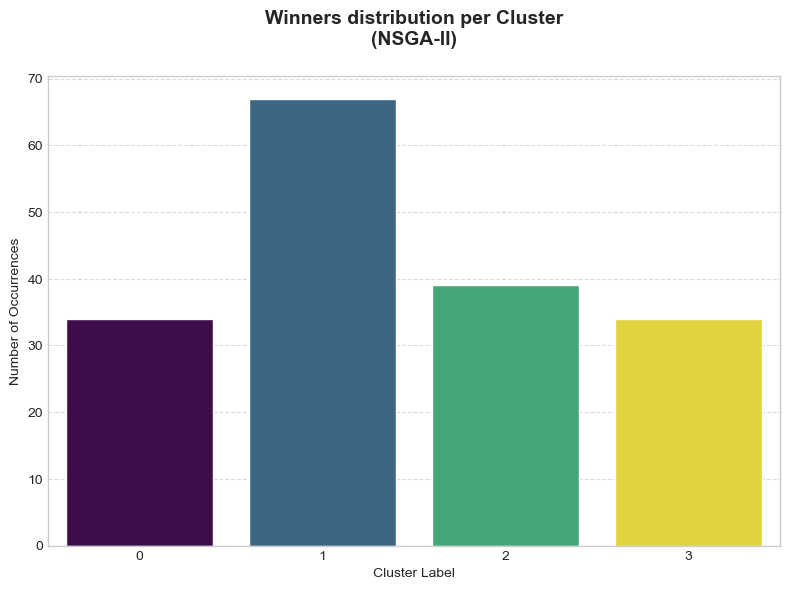

In [1274]:
# --- Plot the distribution of 'cluster' for the filtered data ---
plt.figure(figsize=(8, 6))
sns.countplot(x='cluster', data=data, palette='viridis', hue='cluster', legend=False)
plt.title(f'Winners distribution per Cluster\n({algo})', fontsize=14, fontweight='bold', y=1.05)
plt.xlabel('Cluster Label')
plt.ylabel('Number of Occurrences')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

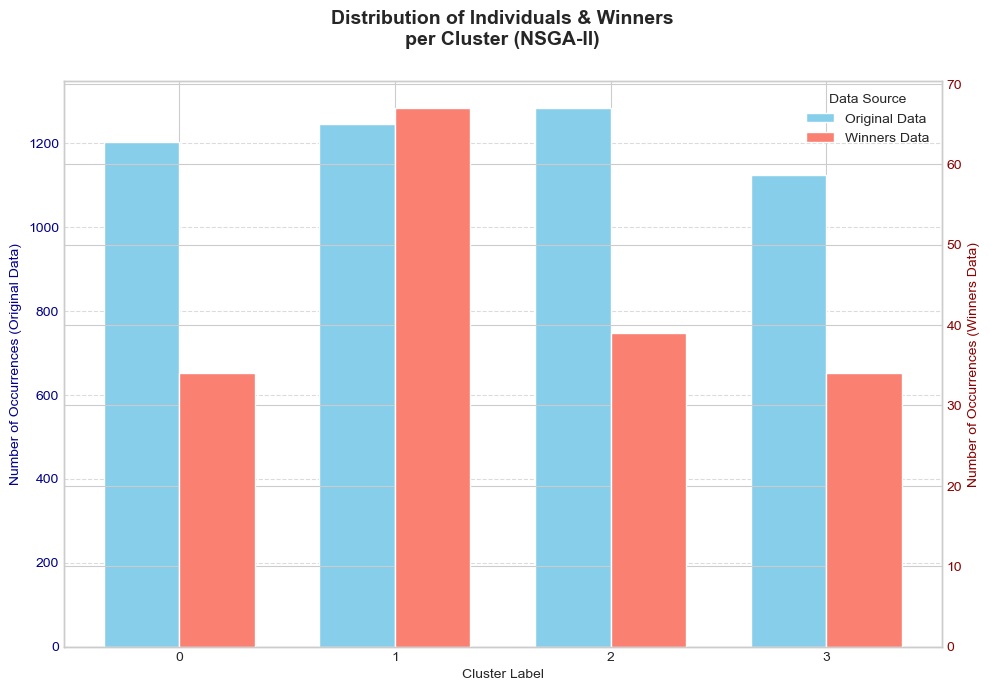

In [1275]:
# 1. Get counts for each dataset
original_counts = df_tsne['cluster'].value_counts().sort_index()
winners_counts = data['cluster'].value_counts().sort_index()

# Align indices to ensure all clusters are present in both series, filling missing with 0
all_clusters = sorted(list(set(original_counts.index) | set(winners_counts.index)))
original_counts = original_counts.reindex(all_clusters, fill_value=0)
winners_counts = winners_counts.reindex(all_clusters, fill_value=0)


# 2. Create the plot with two y-axes
fig, ax1 = plt.subplots(figsize=(10, 7))

# Plot 'Original Data' on the primary y-axis (ax1)
ax1.set_xlabel('Cluster Label')
ax1.set_ylabel('Number of Occurrences (Original Data)', color='darkblue')
ax1.tick_params(axis='y', labelcolor='darkblue')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Create a second y-axis (ax2) sharing the same x-axis
ax2 = ax1.twinx()
bar_width = 0.35
x = range(len(all_clusters)) # Numerical positions for clusters

# Adjust x positions for bars
ax1.bar([p - bar_width/2 for p in x], original_counts.values, bar_width, color='skyblue', label='Original Data')
ax2.bar([p + bar_width/2 for p in x], winners_counts.values, bar_width, color='salmon', label='Winners Data')


ax2.set_ylabel('Number of Occurrences (Winners Data)', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

# Set x-axis labels
ax1.set_xticks(x)
ax1.set_xticklabels(all_clusters)

plt.title(f'Distribution of Individuals & Winners\nper Cluster ({algo})', fontsize=14, fontweight='bold', y=1.05)

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', title='Data Source')

plt.tight_layout()
plt.show()

In [1276]:
# Calculate the average number of occurrences per cluster in the merged DataFrame
cluster_counts = data['cluster'].value_counts().sort_index()
average_occurrences = cluster_counts.mean()
print(f"Average best individuals per cluster: {average_occurrences:.0f}")

best_clusters = []

for cluster, count in enumerate(cluster_counts):
    if count >= average_occurrences: best_clusters.append(int(cluster_counts[cluster_counts == cluster_counts.loc[2]].index[0]))
print(f"Most succesfull clusters were {best_clusters}.")

Average best individuals per cluster: 44
Most succesfull clusters were [2].


In [1277]:
df_best = merged[merged['best']==True].copy()
df_best = df_best.drop(columns=['tsne_component_1','tsne_component_2'])
#df_best = df_best.rename(columns={'best_x': 'best'})
display(df_best)

,index,params,file_size,peaq_score,distortion_index,processing_time,fitness,best,cluster
18,18,"{'ar': '12000', 'sample_fmt': 's16p', 'compres...",76.812500,-3.740,-2.805,0.344770,-0.831717,True,3
19,19,"{'ar': '24000', 'sample_fmt': 's32p', 'compres...",71.023438,-3.724,-2.734,0.359250,-0.763873,True,1
20,20,"{'ar': '8000', 'sample_fmt': 's32p', 'compress...",36.359375,-3.850,-3.441,0.341105,-1.223821,True,3
21,21,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",97.146484,-3.315,-1.670,0.394334,0.480443,True,0
22,22,"{'ar': '16000', 'sample_fmt': 's16p', 'compres...",66.699219,-3.805,-3.137,0.339440,-1.071363,True,3
...,...,...,...,...,...,...,...,...,...
3816,3816,"{'ar': '8000', 'sample_fmt': 's16p', 'compress...",36.992188,-3.849,-3.439,0.960472,-1.267649,True,3
3859,3859,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",53.246094,-3.251,-1.561,0.795844,0.704317,True,1
3996,3996,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",241.242188,-2.637,-0.755,0.932736,2.079062,True,1
3999,3999,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",304.536133,-2.602,-0.716,1.090981,2.060220,True,0


### Just clusters with more winners

In [1278]:
for cluster in best_clusters:
    print("="*100)
    print(f"CLUSTER {cluster} WITH {cluster_counts[cluster]} INDIVIDUALS\n")
    analyze_params(df_best[df_best['cluster']==cluster])
    print("\n\n")

CLUSTER 2 WITH 39 INDIVIDUALS

All unique keys found in 'params' field:
['abr', 'ar', 'b:a', 'compression_level', 'reservoir', 'sample_fmt']


🔐 Key 'abr': All values are consistent and equal to True

🔑 Key 'ar': Values vary. Some examples: ['16000', '44100', '32000', '32000', '32000']
  - Value counts:
44100    26
32000    12
16000     1
Name: count, dtype: int64

🔑 Key 'b:a': Values vary. Some examples: ['95k', '253k', '240k', '269k', '191k']
  - Too many unique values to list all. Top 5:
253k    3
191k    3
240k    2
192k    2
233k    2
Name: count, dtype: int64

🔑 Key 'compression_level': Values vary. Some examples: ['7', '4', '9', '7', '7']
  - Value counts:
9    17
7     6
4     5
0     5
2     3
8     2
3     1
Name: count, dtype: int64

🔑 Key 'reservoir': Values vary. Some examples: ['0', '0', '1', '1', '1']
  - Value counts:
1    33
0     6
Name: count, dtype: int64

🔑 Key 'sample_fmt': Values vary. Some examples: ['fltp', 's16p', 'fltp', 'fltp', 's32p']
  - Value counts:
s16p

### All winners individuals sorted by cluster

In [ ]:
for cluster in list(cluster_counts.index):
    print("="*100)
    print(f"CLUSTER {cluster} WITH {cluster_counts[cluster]} INDIVIDUALS\n")
    analyze_params(df_best[df_best['cluster']==cluster])
    print("\n\n")

CLUSTER 0 WITH 34 INDIVIDUALS

All unique keys found in 'params' field:
['abr', 'aq', 'ar', 'b:a', 'compression_level', 'reservoir', 'sample_fmt']


🔐 Key 'abr': All values are consistent and equal to True

🔑 Key 'aq': Values vary. Some examples: ['9', '5', '5']
  - Value counts:
5    2
9    1
Name: count, dtype: int64

🔐 Key 'ar': All values are consistent and equal to 44100

🔑 Key 'b:a': Values vary. Some examples: ['32k', '32k', '245k', '189k', '32k']
  - Value counts:
32k     4
191k    3
162k    2
187k    2
182k    2
       ..
185k    1
183k    1
184k    1
228k    1
227k    1
Name: count, Length: 22, dtype: int64

🔑 Key 'compression_level': Values vary. Some examples: ['9', '0', '9', '9', '9']
  - Value counts:
4    9
9    8
2    5
0    4
3    3
7    2
8    2
1    1
Name: count, dtype: int64

🔑 Key 'reservoir': Values vary. Some examples: ['1', '1', '1', '1', '1']
  - Value counts:
1    33
0     1
Name: count, dtype: int64

🔑 Key 'sample_fmt': Values vary. Some examples: ['s16p', '

---

### Shared parameters analysis for cluster

In [ ]:
params = analyze_params(df_best[df_best['cluster']==1])

All unique keys found in 'params' field:
['abr', 'aq', 'ar', 'b:a', 'compression_level', 'reservoir', 'sample_fmt']


🔐 Key 'abr': All values are consistent and equal to True

🔑 Key 'aq': Values vary. Some examples: ['9', '6', '6', '5', '6']
  - Value counts:
6    3
5    2
9    1
4    1
2    1
1    1
3    1
Name: count, dtype: int64

🔑 Key 'ar': Values vary. Some examples: ['24000', '24000', '44100', '32000', '44100']
  - Value counts:
44100    64
24000     2
32000     1
Name: count, dtype: int64

🔑 Key 'b:a': Values vary. Some examples: ['32k', '135k', '32k', '135k', '135k']
  - Too many unique values to list all. Top 5:
135k    5
139k    3
132k    3
143k    3
32k     2
Name: count, dtype: int64

🔑 Key 'compression_level': Values vary. Some examples: ['8', '8', '4', '7', '8']
  - Value counts:
9    27
4    20
7     9
8     8
2     1
6     1
0     1
Name: count, dtype: int64

🔑 Key 'reservoir': Values vary. Some examples: ['1', '1', '1', '1', '1']
  - Value counts:
1    57
0    10
Name

In [1297]:
params['params_dict']

19      {'ar': '24000', 'sample_fmt': 's32p', 'compres...
75      {'ar': '24000', 'sample_fmt': 's32p', 'compres...
469     {'ar': '44100', 'sample_fmt': 's16p', 'compres...
508     {'ar': '32000', 'sample_fmt': 's16p', 'compres...
513     {'ar': '44100', 'sample_fmt': 's16p', 'compres...
                              ...                        
3721    {'ar': '44100', 'sample_fmt': 's16p', 'compres...
3738    {'ar': '44100', 'sample_fmt': 's16p', 'compres...
3859    {'ar': '44100', 'sample_fmt': 's16p', 'compres...
3996    {'ar': '44100', 'sample_fmt': 's16p', 'compres...
4133    {'ar': '44100', 'sample_fmt': 's16p', 'compres...
Name: params_dict, Length: 67, dtype: object

In [1304]:
# Get all unique keys across all dictionaries in the 'params_dict' column
all_keys = set()
for params_dict in params['params_dict']:
    all_keys.update(params_dict.keys())

print(f"All unique keys found in 'params' field:\n{sorted(list(all_keys))}\n\n")

# Analyze value distributions for each key
for key in sorted(list(all_keys)):
    values_for_key = [d[key] for d in params['params_dict'] if key in d]
    #print(values_for_key)
    #print()
    series = pd.Series(values_for_key, name=key)
    print(series.value_counts())
    print()

All unique keys found in 'params' field:
['abr', 'aq', 'ar', 'b:a', 'compression_level', 'reservoir', 'sample_fmt']


abr
True    51
Name: count, dtype: int64

aq
6    3
5    2
9    1
4    1
2    1
1    1
3    1
Name: count, dtype: int64

ar
44100    64
24000     2
32000     1
Name: count, dtype: int64

b:a
135k    5
139k    3
132k    3
143k    3
32k     2
       ..
169k    1
180k    1
179k    1
36k     1
177k    1
Name: count, Length: 33, dtype: int64

compression_level
9    27
4    20
7     9
8     8
2     1
6     1
0     1
Name: count, dtype: int64

reservoir
1    57
0    10
Name: count, dtype: int64

sample_fmt
s16p    44
s32p    13
fltp    10
Name: count, dtype: int64



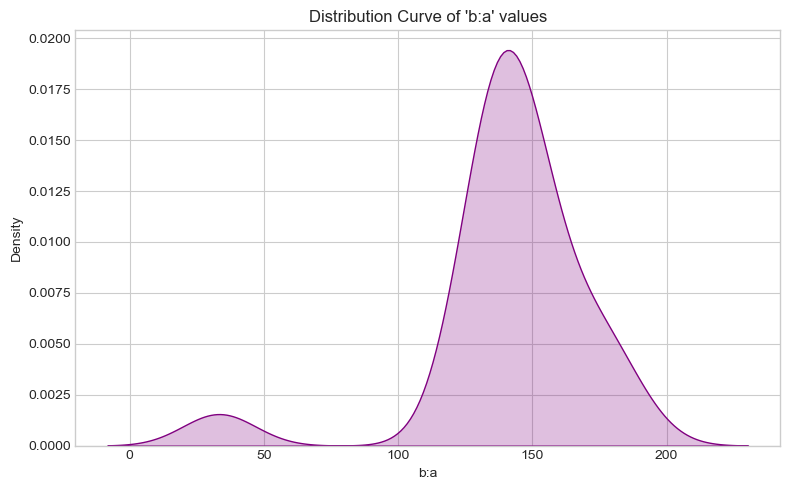

In [ ]:
key = 'b:a'
values_for_key = [int(d[key].replace('k', '')) for d in params['params_dict'] if key in d]
#print(values_for_key)
#print()
series = pd.Series(sorted(values_for_key), name=key)
#print(series.value_counts())

# Plot the distribution
plt.figure(figsize=(8, 5))
sns.histplot(series, kde=True, bins=15, color='skyblue')
plt.title(f"Distribution of '{key}' values")
plt.xlabel(key)
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [1319]:
# Filter 'b:a' values around 150 (e.g., within ±5)
b_a_values = series[(series >= 80)]
mean_ba = b_a_values.mean()
std_ba = b_a_values.std()
print(f"Mean of 'b:a' ~150: {mean_ba:.2f}")
print(f"Std dev of 'b:a' ~150: {std_ba:.2f}")

Mean of 'b:a' ~150: 147.44
Std dev of 'b:a' ~150: 16.18


In [1311]:
series.describe()

count       57
unique      33
top       135k
freq         5
Name: b:a, dtype: object